In [ ]:
# 7.0 Data Collection

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the CSV file
df = pd.read_csv('./data/clean_data.csv')

label_encoder = LabelEncoder()

df['c_focus_math'] = df['c_focus_math'].astype('object')
df['c_difficulty_math'] = df['c_difficulty_math'].astype('object')
df['c_internet_interruption'] = df['c_internet_interruption'].astype('object')

# Get a summary of data types
dtype_summary = df.dtypes.value_counts()

# Format the output
formatted_summary = ', '.join([f"{dtype}({count})" for dtype, count in dtype_summary.items()])

# Display the result
print(f"dtypes: {formatted_summary}")

dtypes: object(11), float64(10)


In [328]:
# 7.1 Data analytics purposes

# 7.1.1 Categorical data
object_columns = df.select_dtypes(include=['object'])

object_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   c_result                 500 non-null    object
 1   c_addmath_gred           500 non-null    object
 2   c_learning_style         500 non-null    object
 3   c_how_preparation        500 non-null    object
 4   c_focus_math             500 non-null    object
 5   c_difficulty_math        500 non-null    object
 6   c_gender                 500 non-null    object
 7   c_on_off_campus          500 non-null    object
 8   c_place_studying         500 non-null    object
 9   c_extracurricular        500 non-null    object
 10  c_internet_interruption  500 non-null    object
dtypes: object(11)
memory usage: 43.1+ KB


In [329]:
# 7.1.1 Categorical data
object_columns = df.select_dtypes(include=['float64'])

object_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   n_hours_studying    500 non-null    float64
 1   n_days_preparation  500 non-null    float64
 2   n_hours_sleep       500 non-null    float64
 3   n_add_materials     500 non-null    float64
 4   n_hours_exercising  500 non-null    float64
 5   n_hours_socmed      500 non-null    float64
 6   n_distance          500 non-null    float64
 7   n_housemate         500 non-null    float64
 8   n_meals             500 non-null    float64
 9   n_devices           500 non-null    float64
dtypes: float64(10)
memory usage: 39.2 KB


In [330]:
# 7.2.1 Label

print(df['c_result'].value_counts())

c_result
Pass / Lulus    250
Fail / Gagal    250
Name: count, dtype: int64


In [331]:
# 7.2.2 Features

df_excluded = df.drop(columns=['c_result'])

# Display the modified DataFrame
df_excluded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   c_addmath_gred           500 non-null    object 
 1   c_learning_style         500 non-null    object 
 2   c_how_preparation        500 non-null    object 
 3   c_focus_math             500 non-null    object 
 4   c_difficulty_math        500 non-null    object 
 5   n_hours_studying         500 non-null    float64
 6   n_days_preparation       500 non-null    float64
 7   n_hours_sleep            500 non-null    float64
 8   c_gender                 500 non-null    object 
 9   c_on_off_campus          500 non-null    object 
 10  c_place_studying         500 non-null    object 
 11  c_extracurricular        500 non-null    object 
 12  c_internet_interruption  500 non-null    object 
 13  n_add_materials          500 non-null    float64
 14  n_hours_exercising       5

In [ ]:
# 8.1.1 Data Cleaning

import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder

# Path to the uploaded CSV file
data = "./data/data.csv"

# Load the CSV file
df = pd.read_csv(data)

# Before cleaning
print(df.isna().sum())

# Remove rows where the specified column contains "No / Tidak"
df = df.drop(df[df['take_calculus'] == 'No / Tidak'].index)

# Drop column timestamp and take_calculus
df = df.drop(columns=['Timestamp', 'take_calculus'])

# After cleaning
print(df.isna().sum())

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save clean data
clean_data = './data/clean_data.csv'
df.to_csv(clean_data, index=False)

Timestamp                   0
take_calculus               0
c_result                   18
c_addmath_gred             18
c_learning_style           18
c_how_preparation          18
c_focus_math               18
c_difficulty_math          18
n_hours_studying           18
n_days_preparation         18
n_hours_sleep              18
c_gender                   18
c_on_off_campus            18
c_place_studying           18
c_extracurricular          18
c_internet_interruption    18
n_add_materials            18
n_hours_exercising         18
n_hours_socmed             18
n_distance                 18
n_housemate                18
n_meals                    18
n_devices                  18
dtype: int64
c_result                   0
c_addmath_gred             0
c_learning_style           0
c_how_preparation          0
c_focus_math               0
c_difficulty_math          0
n_hours_studying           0
n_days_preparation         0
n_hours_sleep              0
c_gender                   0
c_on_of

In [333]:
# 8.1.2 Data Selection

# Define features (X) and target (Y)
X = df.drop(columns=['c_result'])  # Drop the target column for features
Y = df['c_result']  # Assign the target column to Y

# Print columns for X and Y
print("Feature columns (X):", X.columns.tolist())  # Print feature column names
print("Target column (Y):", Y.name)  # Print the name of the target column

Feature columns (X): ['c_addmath_gred', 'c_learning_style', 'c_how_preparation', 'c_focus_math', 'c_difficulty_math', 'n_hours_studying', 'n_days_preparation', 'n_hours_sleep', 'c_gender', 'c_on_off_campus', 'c_place_studying', 'c_extracurricular', 'c_internet_interruption', 'n_add_materials', 'n_hours_exercising', 'n_hours_socmed', 'n_distance', 'n_housemate', 'n_meals', 'n_devices']
Target column (Y): c_result


In [ ]:
# 8.1.3 Data Transformation

# Label encode the categorical variables
var_mod = ['c_result', 'c_addmath_gred', 'c_learning_style', 'c_how_preparation', 
           'c_focus_math', 'c_difficulty_math', 'c_gender', 'c_on_off_campus', 
           'c_place_studying', 'c_extracurricular', 'c_internet_interruption']

le = LabelEncoder()
for i in var_mod:
    df[i] = le.fit_transform(df[i])

from IPython.display import display

# Display the DataFrame
display(df.head())

# Save clean data with label encoder
clean_data_le = './data/clean_data_le.csv'
df.to_csv(clean_data_le, index=False)

print("Results saved to 'clean_data_le.csv'.")

,c_result,c_addmath_gred,c_learning_style,c_how_preparation,c_focus_math,c_difficulty_math,n_hours_studying,n_days_preparation,n_hours_sleep,c_gender,...,c_place_studying,c_extracurricular,c_internet_interruption,n_add_materials,n_hours_exercising,n_hours_socmed,n_distance,n_housemate,n_meals,n_devices
0,1,6,2,2,2,2,4.0,7.0,6.0,0,...,2,1,1,3.0,5.0,4.0,4.0,2.0,2.0,3.0
1,1,1,0,0,3,0,4.0,21.0,8.0,0,...,3,1,1,4.0,3.0,4.0,3.0,4.0,3.0,3.0
2,1,4,2,2,2,4,13.0,14.0,5.0,0,...,2,0,1,3.0,2.0,3.0,1.0,8.0,2.0,3.0
3,1,4,2,2,2,4,12.0,5.0,6.0,1,...,2,1,1,4.0,2.0,7.0,7.0,6.0,2.0,3.0
4,1,7,0,2,2,4,3.0,5.0,7.0,1,...,2,0,1,2.0,2.0,7.0,2.0,8.0,2.0,3.0


Results saved to 'clean_data_le.csv'.


In [ ]:
# 8.2.2.1 Implementation of KNN

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data_clean_le = pd.read_csv("./data/clean_data_le.csv")

# Data slicing: Features and target
x = data_clean_le.iloc[:, 1:21]  # Features (columns 1 to 20)
y = data_clean_le.iloc[:, 0]  # Target (column 0)

# Split dataset into training and testing sets (e.g., 80-20 split)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, shuffle=True)

# Combine features and target for training and testing sets (optional for reference)
train = pd.concat([X_train, y_train], axis=1, sort=False)
test = pd.concat([X_test, y_test], axis=1, sort=False)

# Initialize and train the KNN Classifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Make predictions for training and testing sets
y_train_pred = knn.predict(X_train)  # Predictions on training set
y_test_pred = knn.predict(X_test)    # Predictions on testing set

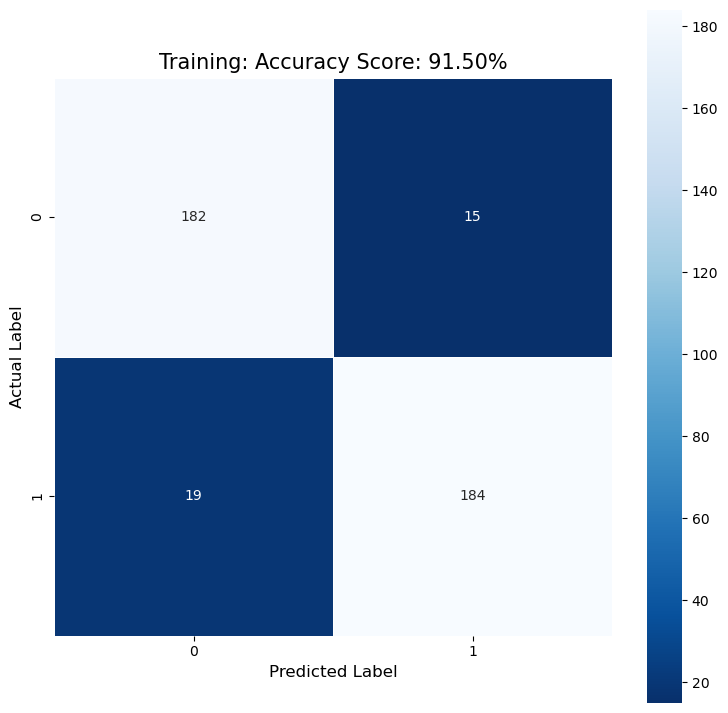

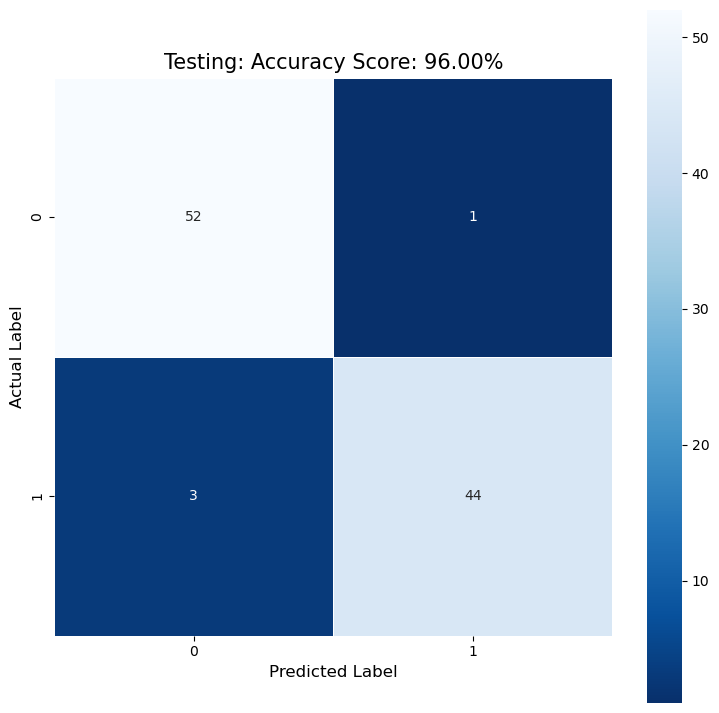

In [336]:
# 8.2.2.2 Data train assessment
train_cm = confusion_matrix(y_train, y_train_pred)
train_accuracy = accuracy_score(y_train, y_train_pred) * 100
plt.figure(figsize=(9, 9))
sns.heatmap(train_cm, fmt='d', annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f"Training: Accuracy Score: {train_accuracy:.2f}%", size=15)
plt.show()

# 8.2.2.2 Data test assessment
test_cm = confusion_matrix(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred) * 100
plt.figure(figsize=(9, 9))
sns.heatmap(test_cm, fmt='d', annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f"Testing: Accuracy Score: {test_accuracy:.2f}%", size=15)
plt.show()

In [ ]:
# 8.2.3 CV K-fold

df = './data/clean_data_le.csv'
dataKFold = pd.read_csv(df)
dataKFold.to_csv(clean_data_le, index=False)

# Initialize KFold
kf = KFold(n_splits=4, shuffle=True, random_state=42)  # 4 splits for k-fold

# Create a counter for naming the files
fold_counter = 1

# Loop through the splits
for train_index, test_index in kf.split(dataKFold):
    # Split the data into training and testing sets
    train_data = dataKFold.iloc[train_index]
    test_data = dataKFold.iloc[test_index]
    
    # Save the training and testing data for this fold to separate files
    train_data.to_csv(f'./data/train_fold_{fold_counter}.csv', index=False)
    test_data.to_csv(f'./data/test_fold_{fold_counter}.csv', index=False)
    
    # Increment the fold counter
    fold_counter += 1

print("Operation is done!")

Operation is done!


In [ ]:
# 8.2.3.1 List of K-Fold Experiments Batch

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import itertools

# Define parameter combinations
n_neighbors_values = [3, 5, 7, 9]
weights_values = ['uniform', 'distance']
algorithm_values = ['auto', 'brute', 'ball_tree', 'kd_tree']
parameter_combinations = list(itertools.product(n_neighbors_values, weights_values, algorithm_values))

# Initialize results storage
results = []

# Loop through each fold and test all parameter combinations
for fold in range(1, 5):  # Folds 1 to 4
    # Load train and test datasets for the current fold
    train_data = pd.read_csv(f"./data/train_fold_{fold}.csv")
    test_data = pd.read_csv(f"./data/test_fold_{fold}.csv")
    
    # Split features and labels
    X_train, y_train = train_data.iloc[:, 1:], train_data.iloc[:, 0]
    X_test, y_test = test_data.iloc[:, 1:], test_data.iloc[:, 0]
    
    # Test each parameter combination
    for params in parameter_combinations:
        n_neighbors, weights, algorithm = params
        
        # Initialize the model
        ModelAKU = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, algorithm=algorithm)
        
        # Train the model
        ModelAKU.fit(X_train, y_train)
        
        # Predict on the training set
        y_train_pred = ModelAKU.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred) * 100
        
        # Predict on the test set
        y_test_pred = ModelAKU.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred) * 100
        
        # Format percentages dynamically
        train_accuracy_str = f"{train_accuracy:.2f}%" if train_accuracy % 1 != 0 else f"{int(train_accuracy)}%"
        test_accuracy_str = f"{test_accuracy:.2f}%" if test_accuracy % 1 != 0 else f"{int(test_accuracy)}%"
        
        # Save the result
        results.append({
            "Fold": fold,
            "n_neighbors": n_neighbors,
            "weights": weights,
            "algorithm": algorithm,
            "Train Accuracy (%)": train_accuracy_str,  # Save as percentage
            "Test Accuracy (%)": test_accuracy_str  # Save as percentage
        })

# Save results to a CSV file in a proper format
results_df = pd.DataFrame(results)
results_df.to_csv("./data/accuracy_comparison.csv", index=False)

print("Results saved to 'accuracy_comparison.csv'.")

Results saved to 'accuracy_comparison.csv'.


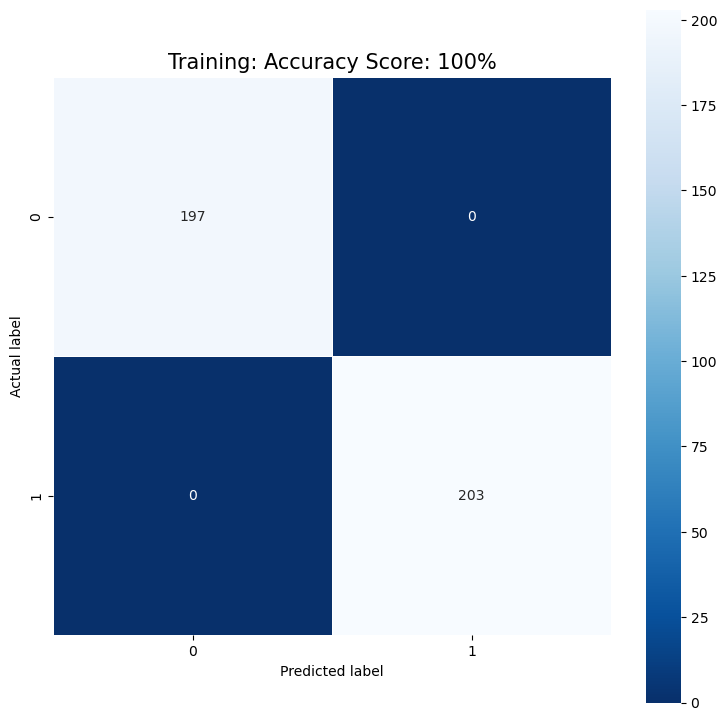

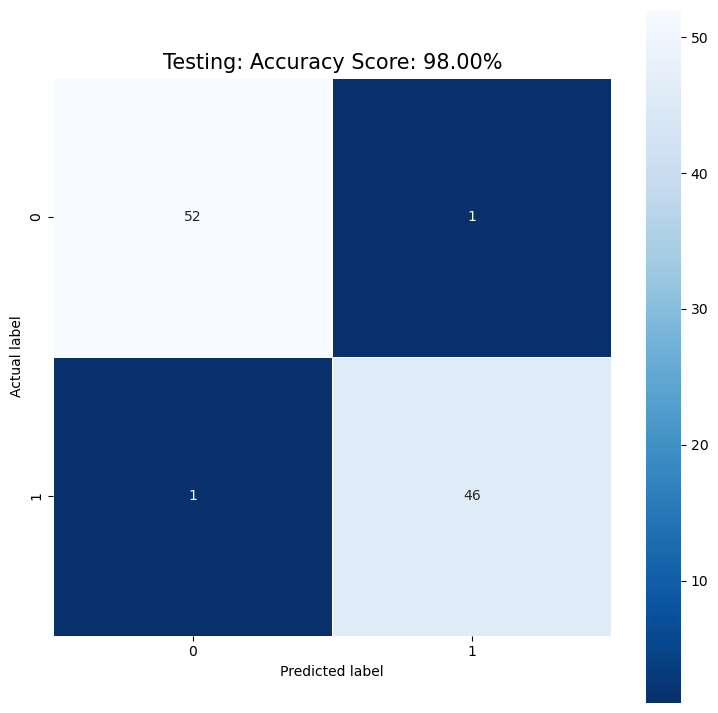

In [ ]:
# 8.2.4 Apply K-Fold result into KNN

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm

# Path to the CSV file
d = pd.read_csv("./data/clean_data_le.csv")

# Data slicing
x = d.iloc[:, 1:21]  # features
y = d.iloc[:, 0:1]  # label

# To split dataset 90-10, 80-20, 70-30, 60-40
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, shuffle=True)

# To combine features and its target 
train = pd.concat([X_train, y_train], axis=1, sort=False)
test = pd.concat([X_test, y_test], axis=1, sort=False)
                 
# Exporting the New Dataset
train.to_csv('./data/train.csv', index = None, header=True)
test.to_csv('./data/test.csv', index = None, header=True)


# 8.2.4.1 Data train assessment

train_csv = pd.read_csv('./data/train.csv')
x = train_csv.iloc[:, 0:20]  # features
y = train_csv.iloc[:, -1]  # label

# Convert dataframe to array
x = x.values
y = y.values
y = y.ravel()

# Initialize and train the model
ModelAKU = KNeighborsClassifier(n_neighbors=3, weights='distance', algorithm='auto')
ModelAKU.fit(x, y)

# Predict on training data
yPred = ModelAKU.predict(x)

# Plot training confusion matrix
plt.figure(figsize=(9, 9))
sns.heatmap(skm.confusion_matrix(y, yPred), fmt= 'd', annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
train_accuracy = skm.accuracy_score(y, yPred) * 100
train_title = f"Training: Accuracy Score: {train_accuracy:.2f}%" if train_accuracy < 100 else "Training: Accuracy Score: 100%"
plt.title(train_title, size=15)
plt.show()

# 8.2.4.1 Data train assessment

test_csv = pd.read_csv("./data/test.csv")

# Data slicing
x2 = test_csv.iloc[:, 0:20]  # features
y2 = test_csv.iloc[:, -1]  # label

# Convert dataframe to array
x2 = x2.values
y2 = y2.values
y2 = y2.ravel()

# Predict on testing data
yPred2 = ModelAKU.predict(x2)

# Plot testing confusion matrix
plt.figure(figsize=(9, 9))
sns.heatmap(skm.confusion_matrix(y2, yPred2), fmt= 'd', annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
test_accuracy = skm.accuracy_score(y2, yPred2) * 100
test_title = f"Testing: Accuracy Score: {test_accuracy:.2f}%" if test_accuracy < 100 else "Testing: Accuracy Score: 100%"
plt.title(test_title, size=15)
plt.show()

In [340]:
# 8.3.1

newData = [[10,2,2,0,4,2,2,6,0,0,1,0,0,1,2,9,6,2,3,4]]

predictionResult = ModelAKU.predict(newData)

if(predictionResult == 1):
    print("Prediction result = Approved")
else:
    print("Prediction result = Rejected")

Prediction result = Rejected


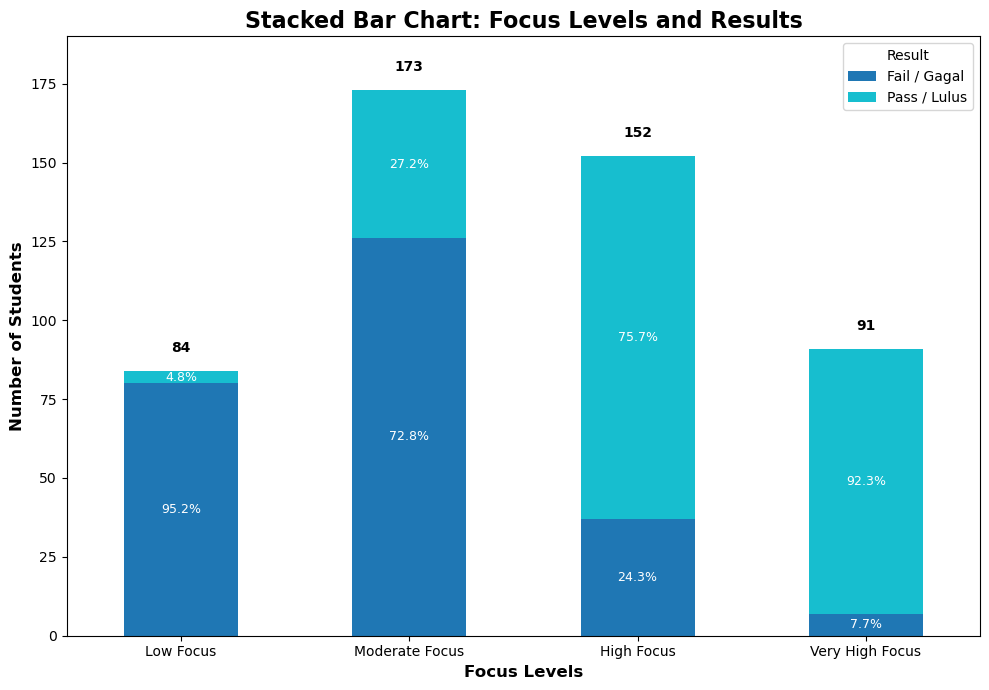

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
clean_data = './data/clean_data.csv'
data_final = pd.read_csv(clean_data)

# Create a mapping dictionary for c_focus_math
focus_mapping = {
    1.0: "Low Focus",
    2.0: "Moderate Focus",
    3.0: "High Focus",
    4.0: "Very High Focus"
}

# Replace c_focus_math values with meaningful words
data_final['c_focus_math'] = data_final['c_focus_math'].map(focus_mapping)

# Ensure the focus levels are ordered correctly
order = ["Low Focus", "Moderate Focus", "High Focus", "Very High Focus"]
data_final['c_focus_math'] = pd.Categorical(data_final['c_focus_math'], categories=order, ordered=True)

# Prepare the data for the stacked bar chart
focus_results = data_final.groupby(['c_focus_math', 'c_result'], observed=False).size().unstack()


# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 7))
bars = focus_results.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

# Calculate totals for each category
totals = focus_results.sum(axis=1)

# Set y-axis limit
ax.set_ylim(0, 190)

# Add totals at the top of each bar
for i, (index, total) in enumerate(totals.items()):
    ax.text(i, total + 5, str(total), ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Add percentages inside each bar segment
for bar in ax.patches:
    # Get bar dimensions
    height = bar.get_height()
    width = bar.get_width()
    x = bar.get_x()
    y = bar.get_y()

    # Use bar index to calculate the group
    group_index = int(round(x))  # Use rounded x to match integer index in totals
    if height > 0:
        percentage = f"{(height / totals.iloc[group_index] * 100):.1f}%"
        ax.text(x + width / 2, y + height / 2, percentage, ha='center', va='center', fontsize=9, color='white')

# Customize the chart
plt.title("Stacked Bar Chart: Focus Levels and Results", fontsize=16, fontweight='bold')
ax.set_xlabel("Focus Levels", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Students", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Result")
plt.tight_layout()
plt.show()

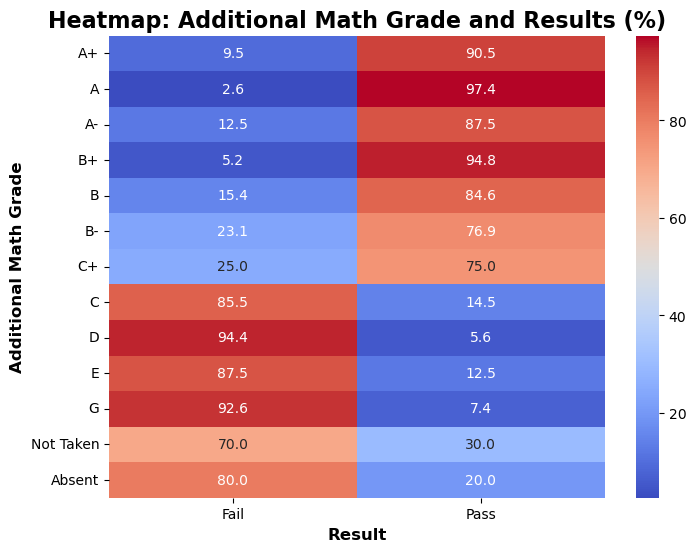

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the desired order for the grades in English
grade_order = [
    "A+", "A", "A-", "B+", "B", "B-", "C+", "C", "D", "E", "G",
    "Not Taken", "Absent"
]

# Define the desired mapping for results
result_mapping = {
    "Pass / Lulus": "Pass",
    "Fail / Gagal": "Fail"
}

# Create a mapping dictionary to convert grades to English
grade_mapping = {
    "A+": "A+",
    "A": "A",
    "A-": "A-",
    "B+": "B+",
    "B": "B",
    "B-": "B-",
    "C+": "C+",
    "C": "C",
    "D": "D",
    "E": "E",
    "G": "G",
    "Not Taken / Tidak Ambil": "Not Taken",
    "TH / Tidak Hadir": "Absent"
}

clean_data = './data/clean_data.csv'
data_final = pd.read_csv(clean_data)

# Map the 'c_addmath_gred' column to English labels
data_final['c_addmath_gred'] = data_final['c_addmath_gred'].map(grade_mapping)

# Map the 'c_result' column to English labels
data_final['c_result'] = data_final['c_result'].map(result_mapping)

# Convert 'c_addmath_gred' to a categorical variable with the specified order
data_final['c_addmath_gred'] = pd.Categorical(
    data_final['c_addmath_gred'], categories=grade_order, ordered=True
)

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.crosstab(data_final['c_addmath_gred'], data_final['c_result'], normalize='index') * 100,
    annot=True, cmap='coolwarm', fmt=".1f"
)
plt.title("Heatmap: Additional Math Grade and Results (%)", fontsize=16, fontweight='bold')
plt.xlabel("Result", fontsize=12, fontweight='bold')
plt.ylabel("Additional Math Grade", fontsize=12, fontweight='bold')
plt.show()

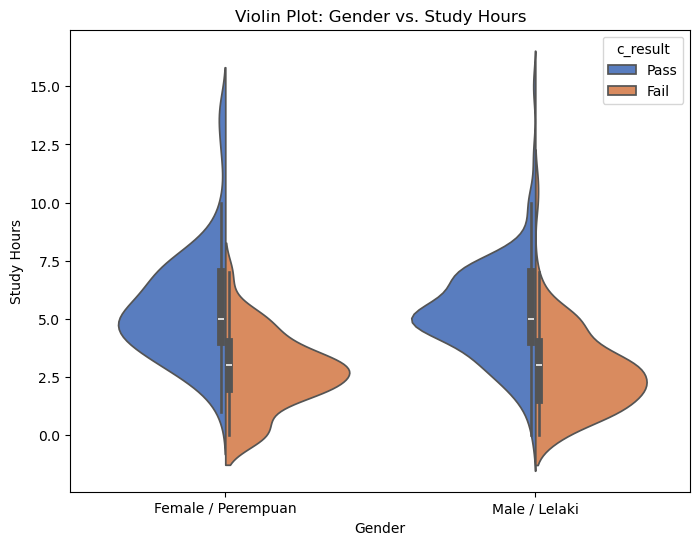

In [343]:
# Visualization 3: Violin Plot of Gender vs. Study Hours
plt.figure(figsize=(8, 6))
sns.violinplot(x='c_gender', y='n_hours_studying', hue='c_result', data=data_final, split=True, palette="muted")
plt.title("Violin Plot: Gender vs. Study Hours")
plt.ylabel("Study Hours")
plt.xlabel("Gender")
plt.show()

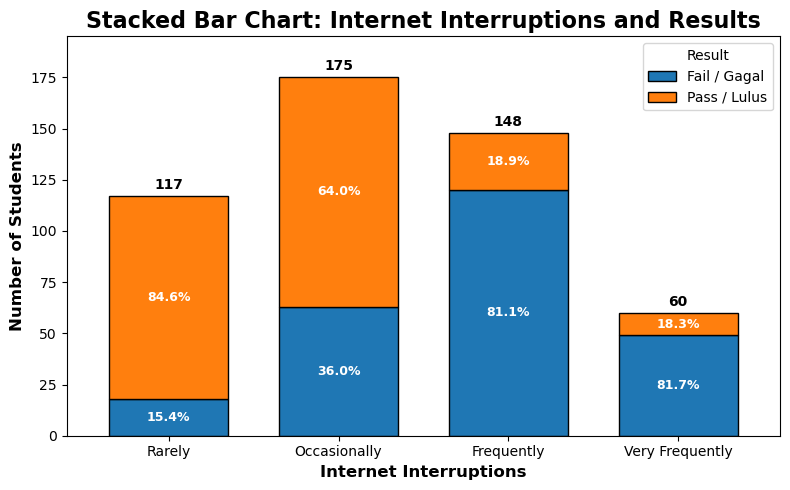

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
clean_data = './data/clean_data.csv'
data_final = pd.read_csv(clean_data)

# Create a mapping dictionary for internet interruptions
internet_mapping = {
    1.0: "Rarely",
    2.0: "Occasionally",
    3.0: "Frequently",
    4.0: "Very Frequently"
}

# Replace c_internet_interruption values with meaningful words
data_final['c_internet_interruption'] = data_final['c_internet_interruption'].map(internet_mapping)

# Ensure the categories are ordered correctly
order = ["Rarely", "Occasionally", "Frequently", "Very Frequently"]
data_final['c_internet_interruption'] = pd.Categorical(
    data_final['c_internet_interruption'], categories=order, ordered=True
)

# Prepare the data for the stacked bar chart
internet_results = data_final.groupby(['c_internet_interruption', 'c_result'], observed=False).size().unstack()

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e']  # Custom colors for "Pass" and "Fail"
bars = internet_results.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', width=0.7)

# Calculate totals for each category
totals = internet_results.sum(axis=1)

# Set y-axis limit dynamically based on totals
ax.set_ylim(0, totals.max() + 20)

# Add totals at the top of each bar
for i, (index, total) in enumerate(totals.items()):
    ax.text(i, total + 2, str(total), ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Add percentages inside each bar segment
for bar in ax.patches:
    # Get bar dimensions
    height = bar.get_height()
    width = bar.get_width()
    x = bar.get_x()
    y = bar.get_y()

    # Use bar index to calculate the group
    group_index = int(round(x))  # Use rounded x to match integer index in totals
    if height > 0:
        percentage = f"{(height / totals.iloc[group_index] * 100):.1f}%"
        ax.text(
            x + width / 2, y + height / 2, percentage, 
            ha='center', va='center', fontsize=9, color='white', fontweight='bold'
        )

# Customize the chart
plt.title("Stacked Bar Chart: Internet Interruptions and Results", fontsize=16, fontweight='bold')
ax.set_xlabel("Internet Interruptions", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Students", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Result", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

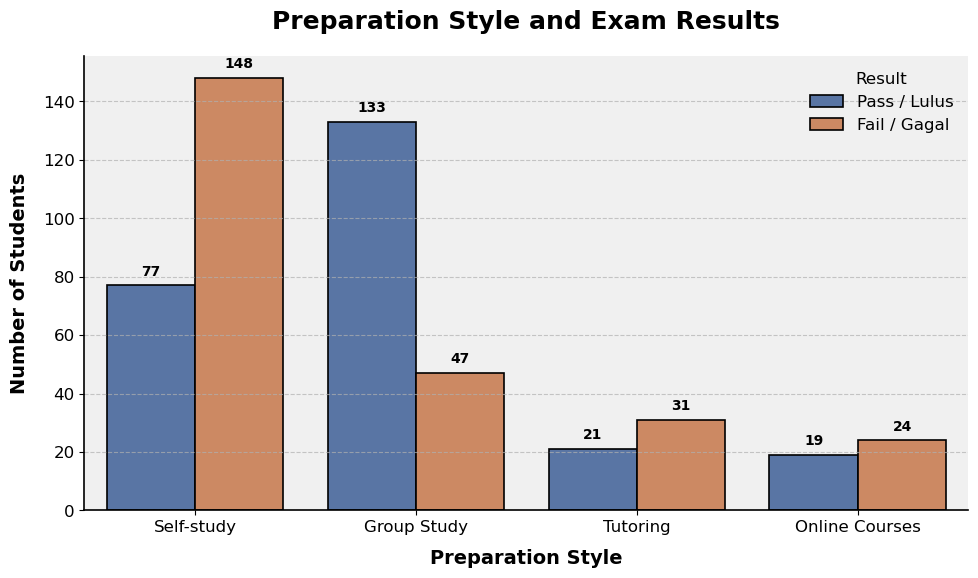

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data and mapping (as before)
clean_data = './data/clean_data.csv'
data_final = pd.read_csv(clean_data)

preparation_mapping = {
    "Self-study / Belajar sendiri": "Self-study",
    "Group Study / Belajar berkumpulan": "Group Study",
    "Tutoring / Tuisyen": "Tutoring",
    "Online Courses / Kursus dalam talian": "Online Courses"
}
data_final['c_how_preparation'] = data_final['c_how_preparation'].replace(preparation_mapping)
order = ["Self-study", "Group Study", "Tutoring", "Online Courses"]

# Calculate percentages for tooltips (for hover effect)
percentage_df = data_final.groupby('c_how_preparation')['c_result'].value_counts(normalize=True).mul(100).reset_index(name='percentage')

# Create the countplot
plt.figure(figsize=(10, 6))  # Slightly larger figure size
ax = sns.countplot(
    data=data_final,
    x='c_how_preparation',
    hue='c_result',
    palette=['#4c72b0', '#dd8452'],  # More distinct and visually appealing colors
    order=order,
    edgecolor='black',  # Add black edges to bars for better definition
    linewidth=1.2 # Make the lines thicker
)

# Set background color
ax.set_facecolor('#f0f0f0') # Set a light gray background

# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

# Customize the chart
plt.title("Preparation Style and Exam Results", fontsize=18, fontweight='bold', pad=20) # Increased title size and padding
plt.xlabel("Preparation Style", fontsize=14, fontweight='bold', labelpad=10) # Increased label size and padding
plt.ylabel("Number of Students", fontsize=14, fontweight='bold', labelpad=10) # Increased label size and padding
plt.xticks(fontsize=12) # Increased tick font size
plt.yticks(fontsize=12) # Increased tick font size
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) # Remove top and right spines
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
plt.legend(title="Result", fontsize=12, title_fontsize=12, frameon=False) # Increased legend font sizes and remove frame
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a subtle grid
plt.tight_layout(pad=1.5) # Increased padding
plt.show()

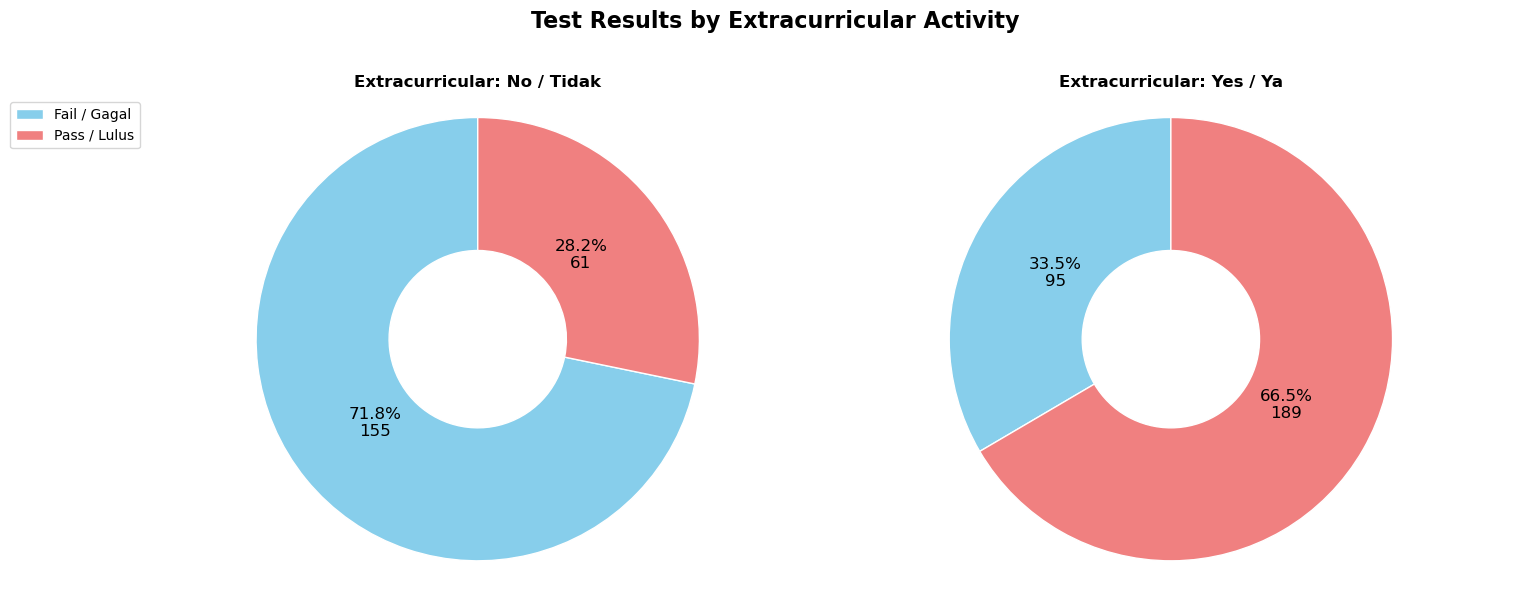

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

clean_data = './data/clean_data.csv'
data_final = pd.read_csv(clean_data)

# Group by extracurricular activity and test result, then count
grouped_data = data_final.groupby(['c_extracurricular', 'c_result']).size().unstack()

# Calculate total students for each extracurricular group
grouped_data['Total'] = grouped_data.sum(axis=1)

# Calculate percentages within each extracurricular group
grouped_data['Pass Percentage'] = (grouped_data['Pass / Lulus'] / grouped_data['Total']) * 100
grouped_data['Fail Percentage'] = (grouped_data['Fail / Gagal'] / grouped_data['Total']) * 100

# Plotting
fig, axes = plt.subplots(1, len(grouped_data.index), figsize=(15, 6))
fig.suptitle("Test Results by Extracurricular Activity", fontsize=16, fontweight='bold')

for i, activity in enumerate(grouped_data.index):
    ax = axes[i]
    data = grouped_data.loc[activity][['Pass Percentage', 'Fail Percentage']]

    # Create the pie chart
    wedges, texts, autotexts = ax.pie(data, autopct='%1.1f%%', startangle=90,
                                      colors=['skyblue', 'lightcoral'],
                                      textprops={'color': 'black', 'fontsize': 10},
                                      wedgeprops=dict(width=0.6, edgecolor='w'))

    # Add counts inside the pie slices (FIX HERE)
    total = grouped_data.loc[activity, 'Total']
    pass_fail_counts = grouped_data.loc[activity][['Pass / Lulus', 'Fail / Gagal']]  # Get the Series

    for j, autotext in enumerate(autotexts):
        try:
            value = pass_fail_counts.iloc[j]  # Use .iloc to access by position
            autotext.set_text(f"{autotext.get_text()}\n{int(value)}")  # Removed () and " Students", increased font size
            autotext.set_fontsize(12) #Increased font size
        except (KeyError, IndexError) as e:
            print(f"Error encountered: {e}. Check your data or the number of categories. Error: {e}")
            continue

    ax.set_title(f"Extracurricular: {activity}", fontsize=12, fontweight='bold')
    ax.axis('equal')

    if i == 0:
        ax.legend(grouped_data.columns[:2], loc='upper left', bbox_to_anchor=(-0.2, 1), fontsize=10)

# Remove unnecessary subplots
if len(grouped_data.index) < len(axes):
    for j in range(len(grouped_data.index), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

On average, students who Pass get 2.09 more hours of sleep per night.


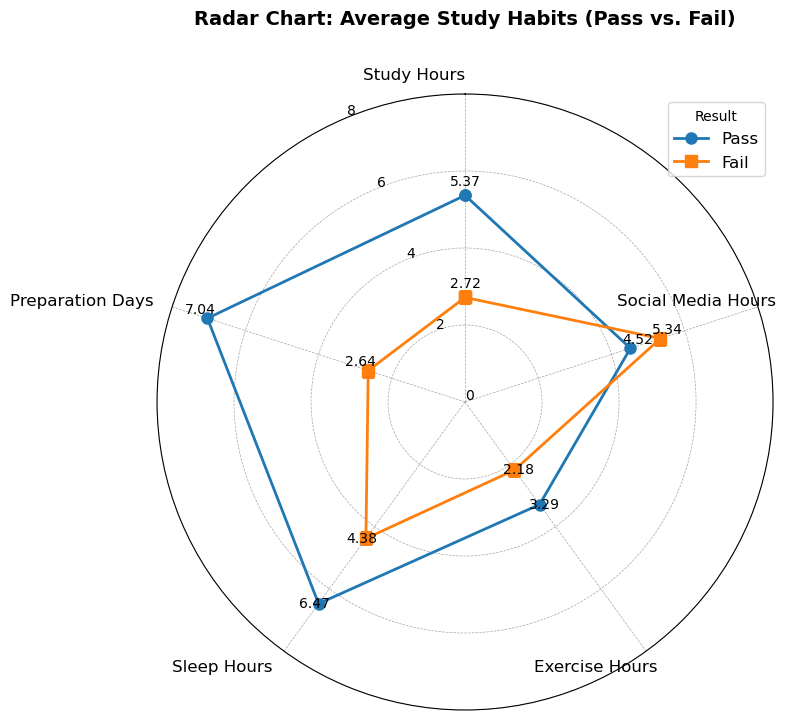

In [365]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your data is loaded into a pandas DataFrame called 'data_final'

categories = {
    'n_hours_studying': 'Study Hours',
    'n_days_preparation': 'Preparation Days',
    'n_hours_sleep': 'Sleep Hours',
    'n_hours_exercising': 'Exercise Hours',
    'n_hours_socmed': 'Social Media Hours'
}

# Calculate means using .loc for label-based indexing
success_means = data_final.loc[data_final['c_result'] == 'Pass / Lulus', categories.keys()].mean()
fail_means = data_final.loc[data_final['c_result'] == 'Fail / Gagal', categories.keys()].mean()

# Convert to numpy arrays *after* using .loc
success_means_np = success_means.values
fail_means_np = fail_means.values

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the polygon (important for fill)
success_means_np = np.concatenate((success_means_np, [success_means_np[0]]))
fail_means_np = np.concatenate((fail_means_np, [fail_means_np[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Adjusted grid with minor ticks
ax.set_rgrids(np.arange(min(min(success_means_np), min(fail_means_np)) - 0.5,
                         max(max(success_means_np), max(fail_means_np)) + 0.5, step=1))
ax.set_theta_zero_location('N')  # Set north as the starting point

# Thicker lines and colorblind-friendly colors
ax.plot(angles, success_means_np, marker='o', markersize=8, linestyle='-', color='tab:blue', label="Pass", linewidth=2)
ax.plot(angles, fail_means_np, marker='s', markersize=8, linestyle='-', color='tab:orange', label="Fail", linewidth=2)

# Rotated category labels with descriptive names
category_labels = [categories[cat] for cat in categories.keys()]
ax.set_xticks(angles[:-1])  # Set ticks before labels (KEY CHANGE)
ax.set_xticklabels(category_labels, rotation=45, ha='right', fontsize=12)

# Data labels with rounding and position adjustment
for angle, value in zip(angles[:-1], success_means_np[:-1]):
    plt.text(angle, value + 0.2, round(value, 2), ha='center', va='bottom', fontsize=10)

for angle, value in zip(angles[:-1], fail_means_np[:-1]):
    plt.text(angle, value + 0.2, round(value, 2), ha='center', va='bottom', fontsize=10)

ax.set_yticks(np.arange(0, max(max(success_means_np), max(fail_means_np)) + 1, step=2))  # Set y-ticks
ax.tick_params(axis='y', which='both', labelsize=10)  # Adjust both major and minor tick labels
plt.legend(title="Result", fontsize=12)
plt.title("Radar Chart: Average Study Habits (Pass vs. Fail)", fontsize=14, fontweight='bold', y=1.1)  # Adjusted title position
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)  # Grid styling

# Calculate and print insights based on sleep data
average_sleep_diff = round(success_means_np[2] - fail_means_np[2], 2)
sleep_label = "Pass" if success_means_np[2] > fail_means_np[2] else "Fail"

print(f"On average, students who {sleep_label} get {average_sleep_diff} more hours of sleep per night.")

C:\Users\Shahzwan\AppData\Local\Temp\ipykernel_14992\1642346949.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  internet_results = data.groupby(['c_internet_interruption', 'c_result']).size().unstack(fill_value=0)
C:\Users\Shahzwan\AppData\Local\Temp\ipykernel_14992\1642346949.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  category_total = totals[int(bar.get_x() + 0.5)]


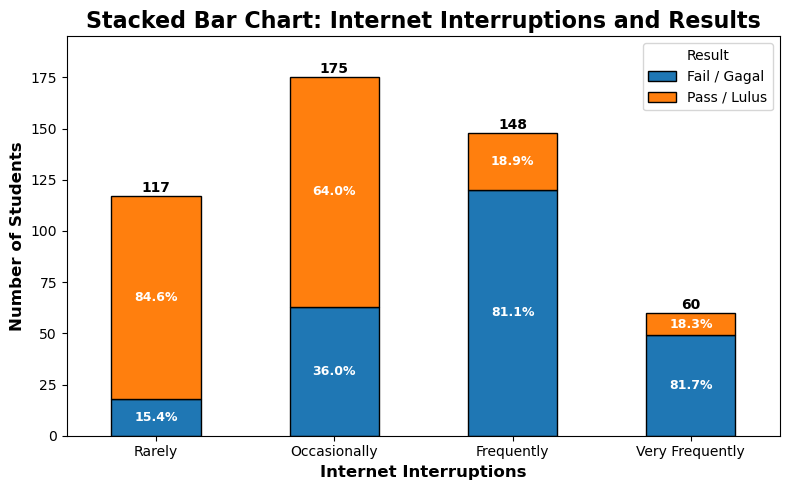

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('./data/clean_data.csv')

# Map and categorize 'c_internet_interruption'
internet_mapping = {1.0: "Rarely", 2.0: "Occasionally", 3.0: "Frequently", 4.0: "Very Frequently"}
data['c_internet_interruption'] = pd.Categorical(data['c_internet_interruption'].map(internet_mapping), 
                                                 categories=["Rarely", "Occasionally", "Frequently", "Very Frequently"], 
                                                 ordered=True)

# Prepare data for plotting
internet_results = data.groupby(['c_internet_interruption', 'c_result']).size().unstack(fill_value=0)
totals = internet_results.sum(axis=1)

# Plot
ax = internet_results.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#1f77b4', '#ff7f0e'], edgecolor='black')
ax.set_ylim(0, totals.max() + 20)
ax.set_title("Stacked Bar Chart: Internet Interruptions and Results", fontsize=16, fontweight='bold')
ax.set_xlabel("Internet Interruptions", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Students", fontsize=12, fontweight='bold')
ax.legend(title="Result", fontsize=10)
plt.xticks(rotation=0)

# Add annotations
for i, total in enumerate(totals):
    ax.text(i, total + 2, str(total), ha='center', fontsize=10, fontweight='bold')
for bar in ax.patches:
    if bar.get_height() > 0:
        height, y = bar.get_height(), bar.get_y()
        category_total = totals[int(bar.get_x() + 0.5)]
        percentage = f"{height / category_total * 100:.1f}%"
        ax.text(bar.get_x() + bar.get_width() / 2, y + height / 2, percentage, 
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


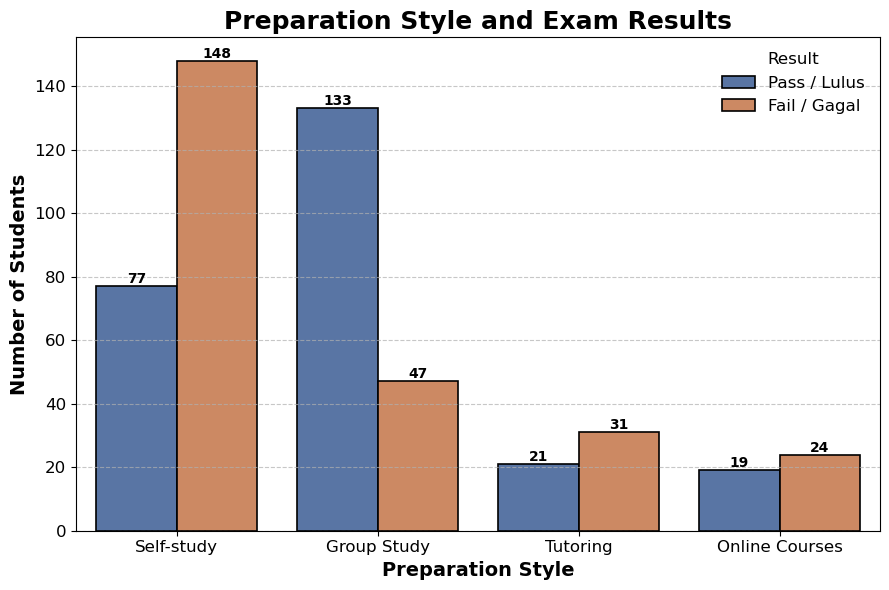

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the dataset after reset
data = pd.read_csv('./data/clean_data.csv')

# Map preparation styles
preparation_mapping = {
    "Self-study / Belajar sendiri": "Self-study",
    "Group Study / Belajar berkumpulan": "Group Study",
    "Tutoring / Tuisyen": "Tutoring",
    "Online Courses / Kursus dalam talian": "Online Courses"
}
data['c_how_preparation'] = data['c_how_preparation'].replace(preparation_mapping)

# Plot
plt.figure(figsize=(9, 6))
ax = sns.countplot(
    data=data,
    x='c_how_preparation',
    hue='c_result',
    palette=['#4c72b0', '#dd8452'],
    order=["Self-study", "Group Study", "Tutoring", "Online Courses"],
    edgecolor='black', linewidth=1.2
)

# Annotate
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize
plt.title("Preparation Style and Exam Results", fontsize=18, fontweight='bold')
plt.xlabel("Preparation Style", fontsize=14, fontweight='bold')
plt.ylabel("Number of Students", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Result", fontsize=12, title_fontsize=12, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


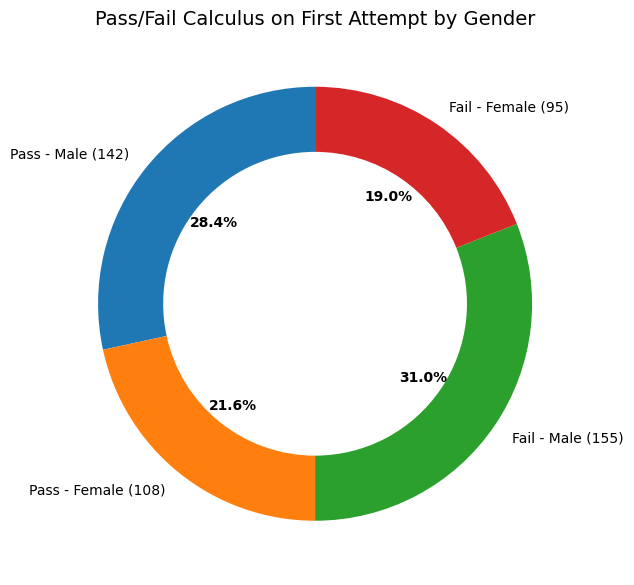

In [19]:
import matplotlib.pyplot as plt

# Data preparation: counting Pass/Fail by Gender
result_gender_counts = data.groupby(['c_result', 'c_gender']).size().unstack(fill_value=0)

# Preparing labels and values for the chart
labels = [
    f"Pass - Male ({result_gender_counts.loc['Pass / Lulus', 'Male / Lelaki']})",
    f"Pass - Female ({result_gender_counts.loc['Pass / Lulus', 'Female / Perempuan']})",
    f"Fail - Male ({result_gender_counts.loc['Fail / Gagal', 'Male / Lelaki']})",
    f"Fail - Female ({result_gender_counts.loc['Fail / Gagal', 'Female / Perempuan']})"
]

values = [
    result_gender_counts.loc['Pass / Lulus', 'Male / Lelaki'],
    result_gender_counts.loc['Pass / Lulus', 'Female / Perempuan'],
    result_gender_counts.loc['Fail / Gagal', 'Male / Lelaki'],
    result_gender_counts.loc['Fail / Gagal', 'Female / Perempuan']
]

# Creating the donut chart
fig, ax = plt.subplots(figsize=(7, 8))
wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90,
    wedgeprops=dict(width=0.3)  # Donut shape
)

# Adding title and formatting
plt.setp(autotexts, size=10, weight="bold")
ax.set_title("Pass/Fail Calculus on First Attempt by Gender", fontsize=14)
plt.show()


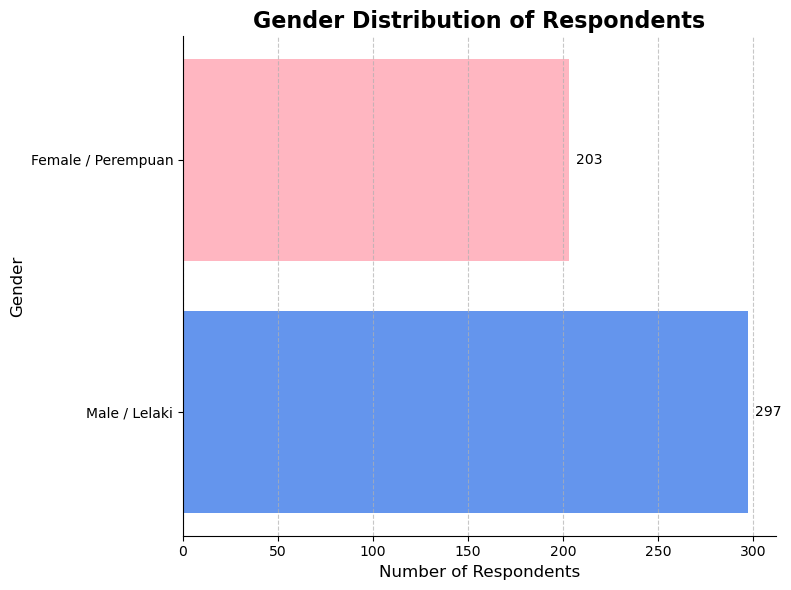

In [24]:
# Redefining the gender_counts to ensure it exists
gender_counts = data['c_gender'].value_counts()

# Creating a horizontal bar chart with softer, eye-catching colors
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(
    gender_counts.index, 
    gender_counts, 
    color=['#6495ED', '#FFB6C1']  # Cornflower blue and light pink
)

# Adding labels and title
ax.set_title("Gender Distribution of Respondents", fontsize=16, fontweight='bold')
ax.set_xlabel("Number of Respondents", fontsize=12)
ax.set_ylabel("Gender", fontsize=12)
ax.bar_label(bars, fmt='%d', padding=5, fontsize=10)

# Enhancing the layout for a polished look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Importing necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Reloading the dataset with the newly uploaded file
data = pd.read_csv('./data/clean_data.csv')



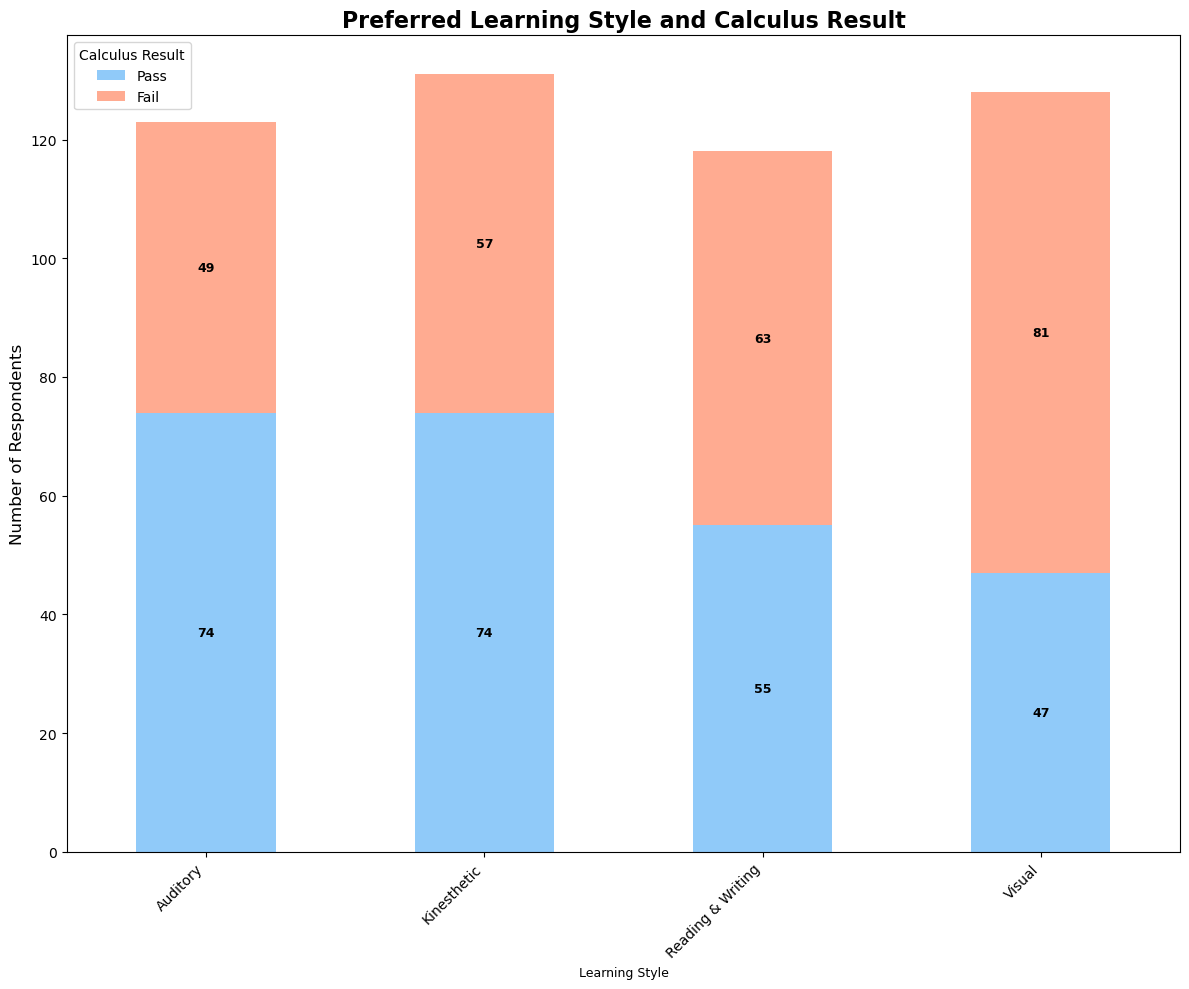

In [135]:
# Grouping data by learning style and result
learning_style_result = data.groupby(['c_learning_style', 'c_result']).size().unstack(fill_value=0)

# Creating a stacked bar chart
fig, ax = plt.subplots(figsize=(12, 10))
bars = learning_style_result.plot(kind='bar', stacked=True, ax=ax, color=['#90CAF9', '#FFAB91'])

# Adding data labels
for bar in bars.patches:
    if bar.get_height() > 0:  # Add labels only for non-zero bars
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Center of the bar
            bar.get_y() + bar.get_height() / 2,  # Center of the bar segment
            f"{int(bar.get_height())}",  # Data value
            ha='center', va='center', fontsize=9, color='black', weight='bold'
        )

# Adding labels, title, and legend
ax.set_title("Preferred Learning Style and Calculus Result", fontsize=16, fontweight='bold')
ax.set_xlabel("Learning Style", fontsize=9)
ax.set_ylabel("Number of Respondents", fontsize=12)
ax.legend(title="Calculus Result", labels=["Pass", "Fail"], fontsize=10)
plt.xticks(rotation=45, ha='right')

# Enhancing layout
plt.tight_layout()
plt.show()


In [63]:
# Updating the focus level mapping to include "Excellent"
def map_focus_level(focus):
    if focus <= 2:
        return 'Low'
    elif focus == 3:
        return 'Medium'
    elif focus == 4:
        return 'High'
    else:
        return 'Excellent'

# Apply updated mapping to focus levels
data['Focus_Level'] = data['c_focus_math'].apply(map_focus_level)

# Grouping by Focus Level and Results
focus_results = data.groupby(['Focus_Level', 'c_result']).size().unstack(fill_value=0)

# Preparing data for visualization
focus_categories = focus_results.index
pass_values = focus_results['Pass / Lulus']
fail_values = focus_results['Fail / Gagal']

# Creating a stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(focus_categories, pass_values, label='Pass', color='#90EE90')  # Light green for Pass
ax.bar(focus_categories, fail_values, bottom=pass_values, label='Fail', color='#FFB6C1')  # Light pink for Fail

# Adding labels and title
ax.set_title("Focus Level in Mathematics Subject with Results", fontsize=16, fontweight='bold')
ax.set_xlabel("Focus Level", fontsize=12)
ax.set_ylabel("Number of Respondents", fontsize=12)
ax.legend(title="Results", fontsize=10)

# Enhancing layout
plt.tight_layout()
plt.show()


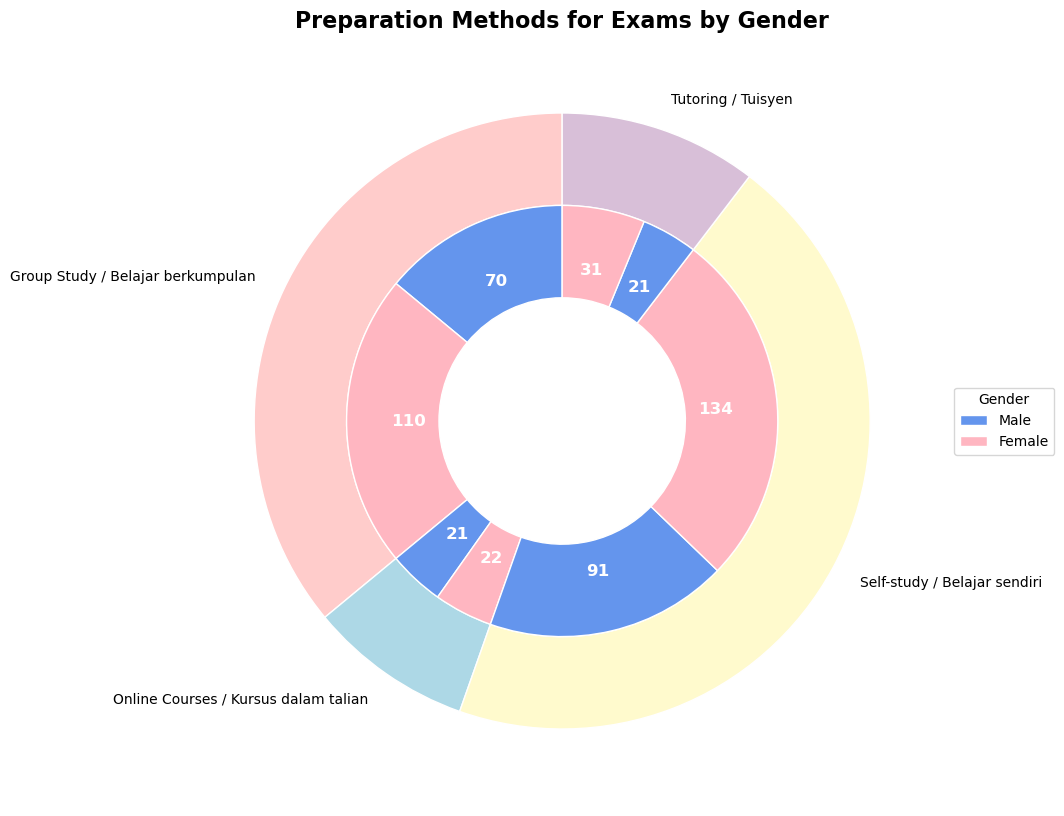

In [86]:
import math
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Creating data
outer_colors = ['#FFCCCB', '#ADD8E6', '#FFFACD', '#D8BFD8']
inner_colors = ['#6495ED', '#FFB6C1'] * len(preparation_gender.index)

# Creating the chart
fig, ax = plt.subplots(figsize=(10, 10))
outer_ring, _ = ax.pie(
    outer_values, labels=outer_labels, radius=1, wedgeprops=dict(width=0.3, edgecolor='w'),
    startangle=90, colors=outer_colors
)
inner_ring, _ = ax.pie(
    inner_values, radius=0.7, wedgeprops=dict(width=0.3, edgecolor='w'),
    startangle=90, colors=inner_colors
)

# Adding numbers in the second inner ring
for i, wedge in enumerate(inner_ring):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x, y = 0.5 * math.cos(math.radians(angle)), 0.5 * math.sin(math.radians(angle))
    ax.text(x, y, inner_labels[i], fontsize=12, fontweight='bold', color='white', ha='center', va='center')

# Adding a legend with matching colors
ax.legend(
    handles=[Patch(facecolor='#6495ED', edgecolor='w', label='Male'),
             Patch(facecolor='#FFB6C1', edgecolor='w', label='Female')],
    title="Gender", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10
)

# Title
ax.set_title("Preparation Methods for Exams by Gender", fontsize=16, fontweight='bold')

plt.show()


In [ ]:
# Importing necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Reloading the dataset with the newly uploaded file
data = pd.read_csv('./data/clean_data.csv')



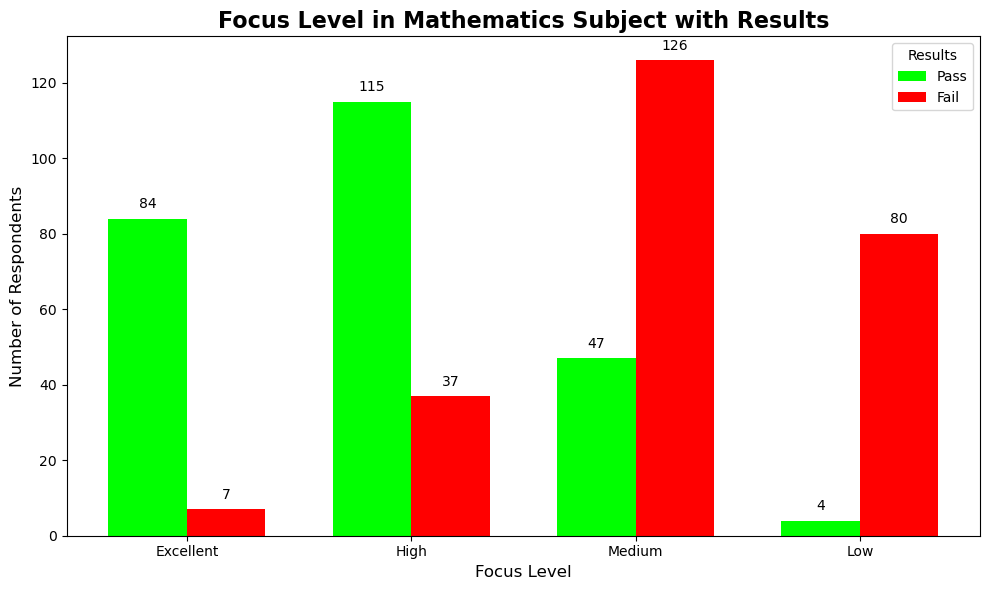

In [98]:
# Creating a bar chart with separate bars for Pass and Fail, including a legend
fig, ax = plt.subplots(figsize=(10, 6))

# Creating separate bars for Pass and Fail
bar_width = 0.35  # Width of each bar
x = range(len(focus_categories))  # X positions for the bars

bars_pass = ax.bar([pos - bar_width/2 for pos in x], pass_values, width=bar_width, label='Pass', color='lime')  # Light green for Pass
bars_fail = ax.bar([pos + bar_width/2 for pos in x], fail_values, width=bar_width, label='Fail', color='red')  # Light pink for Fail

# Adding data labels to each bar
for bar in bars_pass:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, int(bar.get_height()), ha='center', va='bottom', fontsize=10)

for bar in bars_fail:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, int(bar.get_height()), ha='center', va='bottom', fontsize=10)

# Adding labels, title, and legend
ax.set_title("Focus Level in Mathematics Subject with Results", fontsize=16, fontweight='bold')
ax.set_xlabel("Focus Level", fontsize=12)
ax.set_ylabel("Number of Respondents", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(focus_categories, fontsize=10)
ax.legend(title="Results", fontsize=10)

# Enhancing layout
plt.tight_layout()
plt.show()


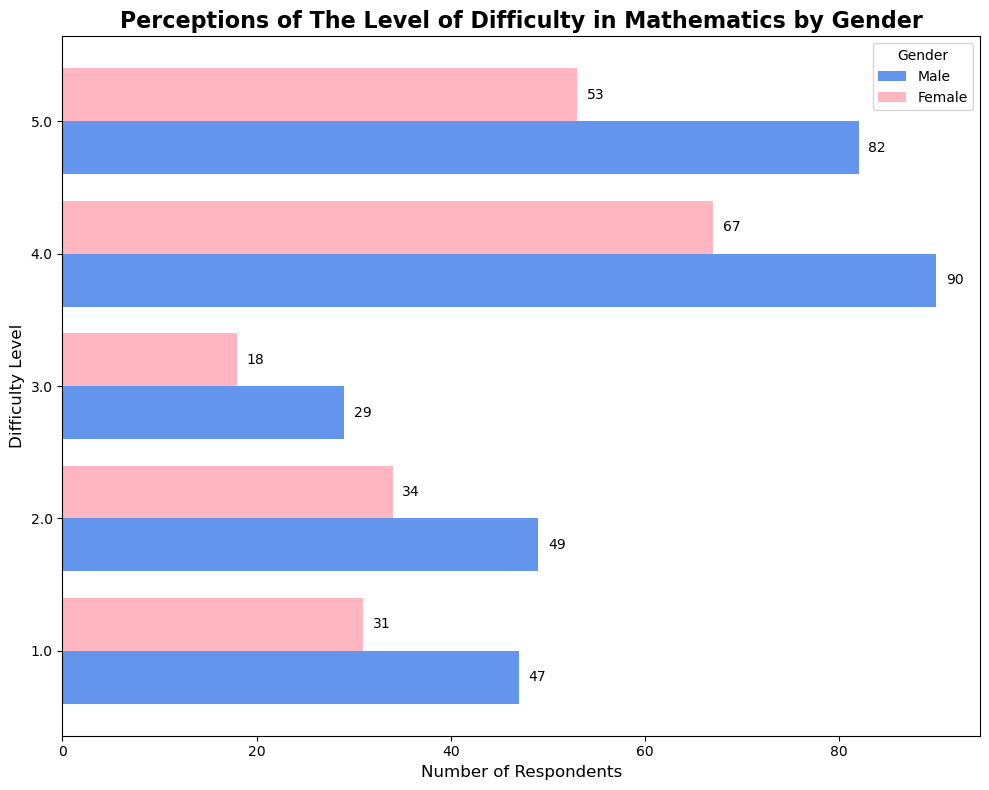

In [102]:
# Grouping data by perceptions of difficulty in mathematics and gender
difficulty_gender = data.groupby(['c_difficulty_math', 'c_gender']).size().unstack(fill_value=0)

# Preparing data for visualization
difficulty_levels = difficulty_gender.index
male_values = difficulty_gender['Male / Lelaki']
female_values = difficulty_gender['Female / Perempuan']

# Creating a grouped horizontal bar chart for better comparison
fig, ax = plt.subplots(figsize=(10, 8))
bar_width = 0.4

# Positions for the bars
positions = range(len(difficulty_levels))

# Plotting the bars
bars_male = ax.barh(
    [p - bar_width/2 for p in positions], male_values, bar_width,
    label='Male', color='#6495ED'
)
bars_female = ax.barh(
    [p + bar_width/2 for p in positions], female_values, bar_width,
    label='Female', color='#FFB6C1'
)

# Adding data labels
for bar in bars_male:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, int(bar.get_width()), va='center', fontsize=10)
for bar in bars_female:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, int(bar.get_width()), va='center', fontsize=10)

# Adding labels, title, and legend
ax.set_title("Perceptions of The Level of Difficulty in Mathematics by Gender", fontsize=16, fontweight='bold')
ax.set_xlabel("Number of Respondents", fontsize=12)
ax.set_ylabel("Difficulty Level", fontsize=12)
ax.set_yticks(positions)
ax.set_yticklabels(difficulty_levels, fontsize=10)
ax.legend(title="Gender", fontsize=10)

# Enhancing layout
plt.tight_layout()
plt.show()


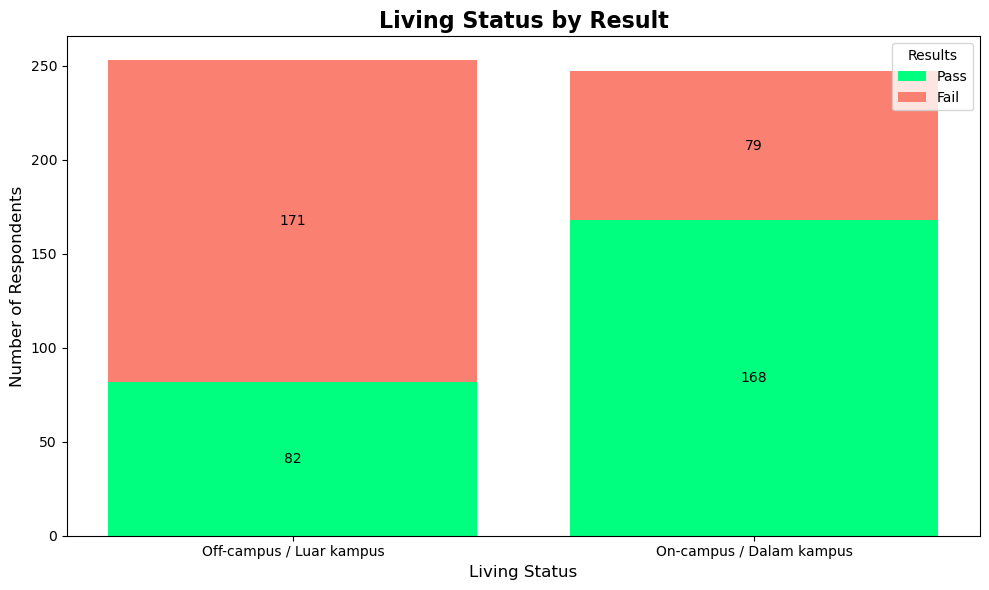

In [126]:
# Grouping data by living status and results
living_status_result = data.groupby(['c_on_off_campus', 'c_result']).size().unstack(fill_value=0)

# Preparing data for visualization
living_status = living_status_result.index
pass_values = living_status_result['Pass / Lulus']
fail_values = living_status_result['Fail / Gagal']

# Creating a stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(living_status, pass_values, label='Pass', color='springgreen')  # Light green for Pass
bars_fail = ax.bar(living_status, fail_values, bottom=pass_values, label='Fail', color='salmon')  # Light pink for Fail

# Adding data labels in the middle of each bar segment
for bar, value in zip(bars, pass_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, int(value), ha='center', va='center', fontsize=10)
for bar, value, base in zip(bars_fail, fail_values, pass_values):
    ax.text(bar.get_x() + bar.get_width() / 2, base + value / 2, int(value), ha='center', va='center', fontsize=10)

# Adding labels, title, and legend
ax.set_title("Living Status by Result", fontsize=16, fontweight='bold')
ax.set_xlabel("Living Status", fontsize=12)
ax.set_ylabel("Number of Respondents", fontsize=12)
ax.legend(title="Results", fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))

# Enhancing layout
plt.tight_layout()
plt.show()


In [ ]:
# Importing necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Reloading the dataset with the newly uploaded file
data = pd.read_csv('./data/clean_data.csv')



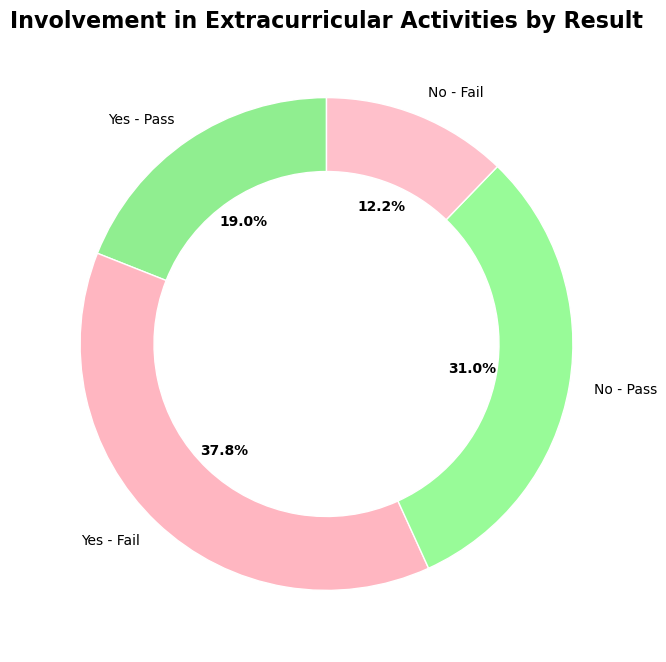

In [133]:
# Grouping data by extracurricular involvement and result
extracurricular_results = data.groupby(['c_extracurricular', 'c_result']).size().unstack(fill_value=0)

# Preparing data for a ring (donut) chart
involvement_labels = ['Yes - Pass', 'Yes - Fail', 'No - Pass', 'No - Fail']
involvement_values = [
    extracurricular_results.loc['Yes / Ya', 'Pass / Lulus'],
    extracurricular_results.loc['Yes / Ya', 'Fail / Gagal'],
    extracurricular_results.loc['No / Tidak', 'Pass / Lulus'],
    extracurricular_results.loc['No / Tidak', 'Fail / Gagal']
]

# Colors for the segments
colors = ['#90EE90', '#FFB6C1', '#98FB98', '#FFC0CB']

# Creating the ring chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    involvement_values, 
    labels=involvement_labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    wedgeprops=dict(width=0.3, edgecolor='w'),  # Creating a ring chart
    colors=colors
)

# Adding a title and formatting
plt.setp(autotexts, size=10, weight="bold")
ax.set_title("Involvement in Extracurricular Activities by Result", fontsize=16, fontweight='bold')
plt.show()


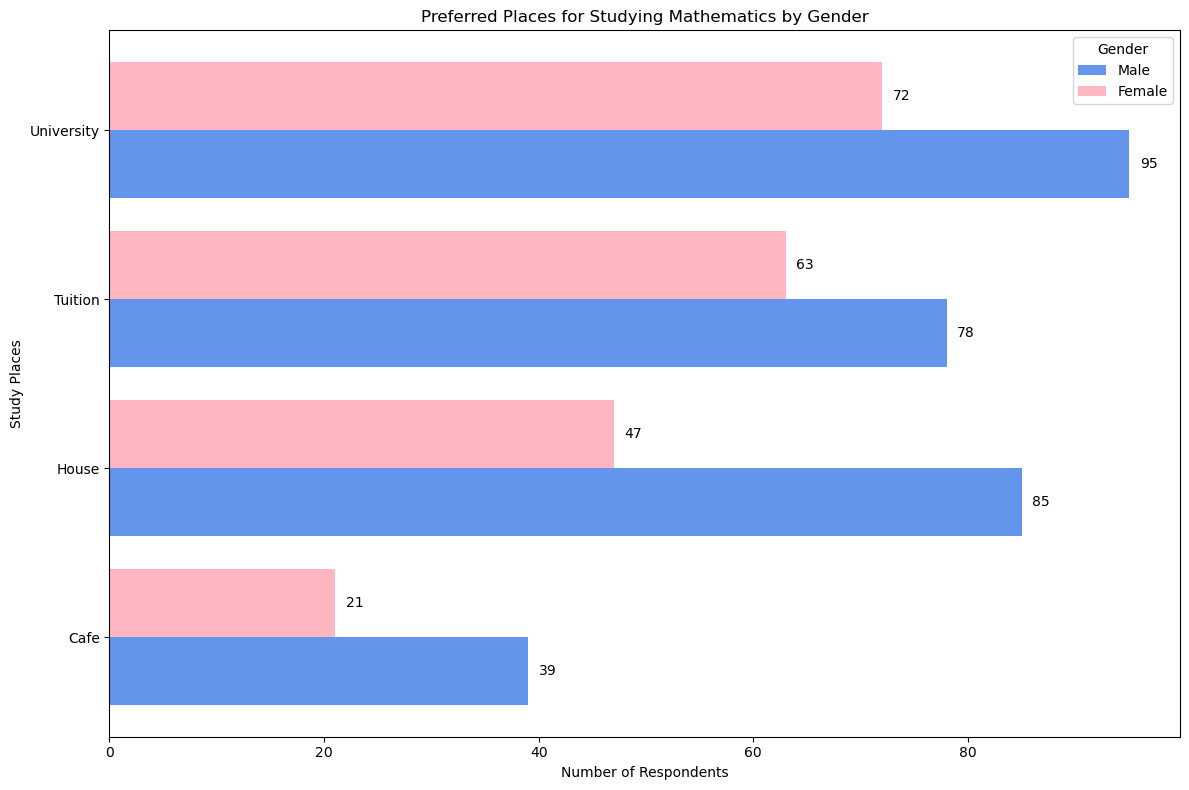

In [141]:
# Mapping study places to simplified labels
place_mapping = {
    'At school or university / Di sekolah atau universiti (e.g., classroom, library)': 'University',
    'At home / Di rumah (e.g., bedroom, study room)': 'House',
    'At cafes or other public spaces / Kafe atau tempat umum lain': 'Cafe',
    'At a tuition center or with a private tutor / Di pusat tuisyen atau tutor persendirian': 'Tuition'
}
data['c_place_studying'] = data['c_place_studying'].map(place_mapping)

# Grouping data
study_places_gender = data.groupby(['c_place_studying', 'c_gender']).size().unstack(fill_value=0)

# Creating a grouped horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
positions = range(len(study_places_gender.index))
bar_width = 0.4

# Plotting the bars for males and females
bars_male = ax.barh(
    [p - bar_width/2 for p in positions], study_places_gender['Male / Lelaki'], 
    bar_width, label='Male', color='#6495ED'
)
bars_female = ax.barh(
    [p + bar_width/2 for p in positions], study_places_gender['Female / Perempuan'], 
    bar_width, label='Female', color='#FFB6C1'
)

# Adding data labels
for bars in [bars_male, bars_female]:
    for bar in bars:
        ax.text(
            bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            int(bar.get_width()), va='center', fontsize=10
        )

# Adding labels, title, and legend
ax.set(title="Preferred Places for Studying Mathematics by Gender", 
       xlabel="Number of Respondents", ylabel="Study Places")
ax.set_yticks(positions)
ax.set_yticklabels(study_places_gender.index)
ax.legend(title="Gender", fontsize=10)

plt.tight_layout()
plt.show()


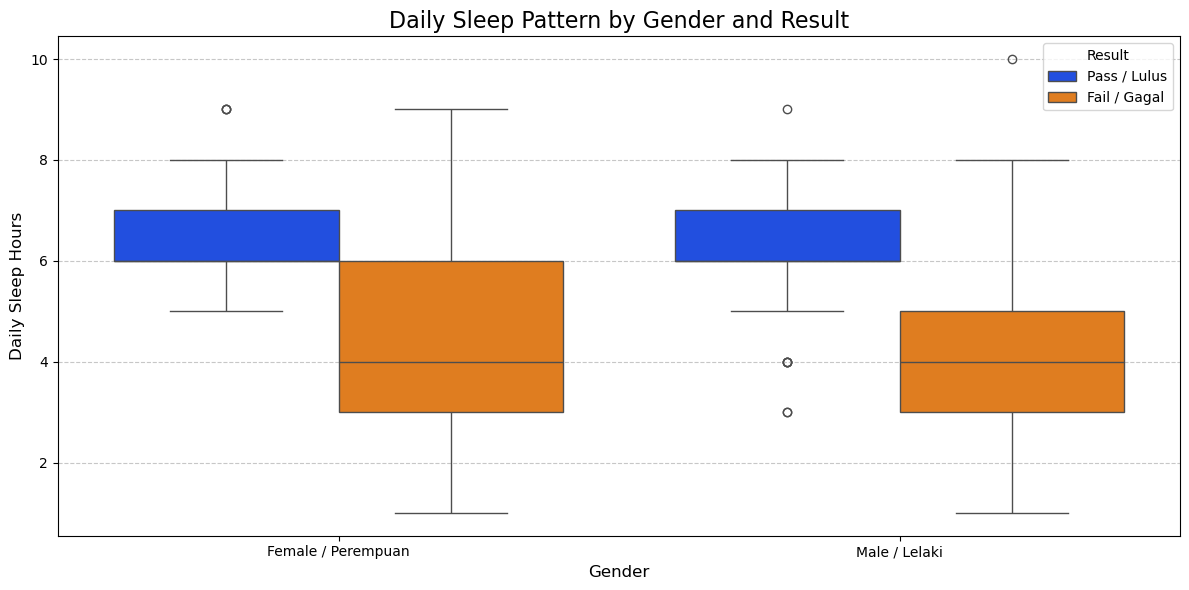

In [155]:
# Re-extracting relevant data in case the variable was cleared
sleep_data = data[['n_hours_sleep', 'c_gender', 'c_result']].dropna()

# Replotting with brighter colors
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=sleep_data, 
    x='c_gender', 
    y='n_hours_sleep', 
    hue='c_result', 
    palette='bright'
)

# Customizing the plot
plt.title('Daily Sleep Pattern by Gender and Result', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Daily Sleep Hours', fontsize=12)
plt.legend(title='Result', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Importing necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Reloading the dataset with the newly uploaded file
data = pd.read_csv('./data/clean_data.csv')



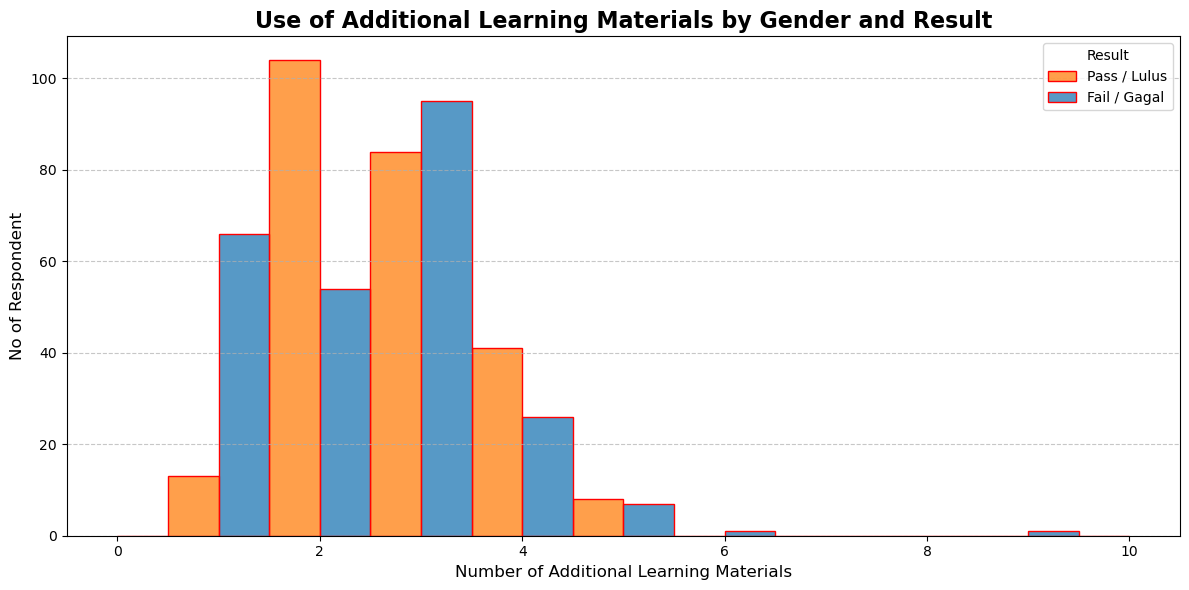

In [154]:
# Adding a parameter to change the bar color and ensuring the legend is displayed
def plot_learning_materials_histogram_with_color(bar_color='blue', edge_color='black'):
    plt.figure(figsize=(12, 6))
    sns.histplot(
        data=learning_material_data, 
        x='n_add_materials', 
        hue='c_result', 
        multiple='dodge', 
        kde=False,
        bins=10,
        color=bar_color,
        edgecolor=edge_color
    )
    
    # Customizing the plot
    plt.title('Use of Additional Learning Materials by Gender and Result', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Additional Learning Materials', fontsize=12)
    plt.ylabel('No of Respondent', fontsize=12)
    plt.legend(title='Result', labels=['Pass / Lulus', 'Fail / Gagal'], fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage of the function with specified bar and edge colors
plot_learning_materials_histogram_with_color(bar_color='orange', edge_color='red')


In [ ]:
# Importing necessary libraries after reset
import pandas as pd
import matplotlib.pyplot as plt

# Reloading the dataset with the newly uploaded file
data = pd.read_csv('./data/clean_data.csv')



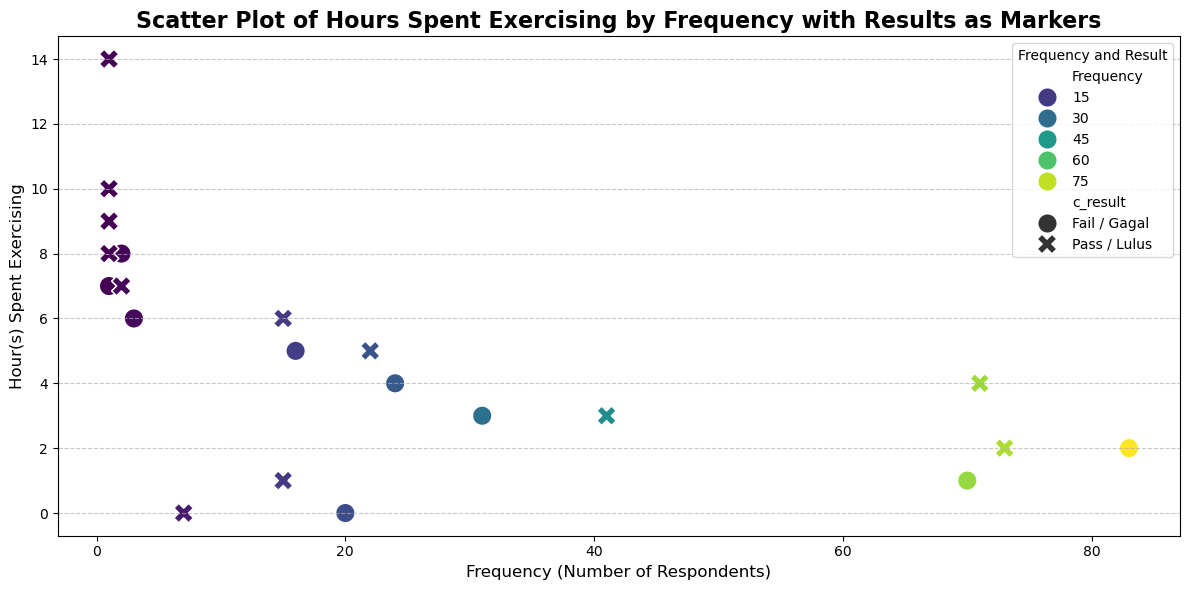

In [169]:
# Re-extracting relevant columns to ensure exercise_data is defined
exercise_data = data[['n_hours_exercising', 'c_gender', 'c_result']].dropna()

# Recalculating the frequency data
exercise_frequency = exercise_data.groupby(['n_hours_exercising', 'c_result']).size().reset_index(name='Frequency')

# Creating the scatter plot with distinct colors for frequency
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=exercise_frequency,
    x='Frequency',
    y='n_hours_exercising',
    hue='Frequency',  # Color represents frequency
    style='c_result',  # Use different markers for results
    palette='viridis',  # More distinct color palette
    s=200  # Size of the markers
)

# Customizing the plot
plt.title('Scatter Plot of Hours Spent Exercising by Frequency with Results as Markers', fontsize=16, fontweight='bold')
plt.xlabel('Frequency (Number of Respondents)', fontsize=12)
plt.ylabel('Hour(s) Spent Exercising', fontsize=12)
plt.legend(title='Frequency and Result', fontsize=10, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


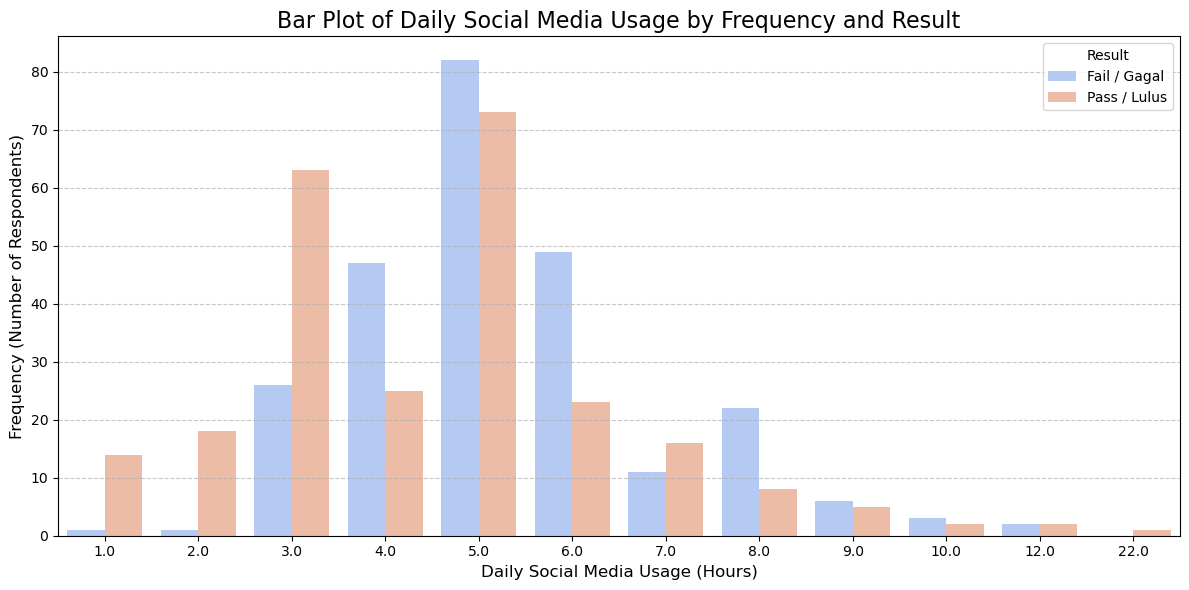

In [168]:
# Re-extracting relevant columns to ensure social_media_data is defined
social_media_data = data[['n_hours_socmed', 'c_result']].dropna()

# Recalculating the frequency data
social_media_frequency = social_media_data.groupby(['n_hours_socmed', 'c_result']).size().reset_index(name='Frequency')

# Creating a bar plot to visualize Daily Social Media Usage with frequency and result
plt.figure(figsize=(12, 6))
sns.barplot(
    data=social_media_frequency,
    x='n_hours_socmed',
    y='Frequency',
    hue='c_result',  
    palette='coolwarm'  
)

# Customizing the plot
plt.title('Bar Plot of Daily Social Media Usage by Frequency and Result', fontsize=16, )
plt.xlabel('Daily Social Media Usage (Hours)', fontsize=12)
plt.ylabel('Frequency (Number of Respondents)', fontsize=12)
plt.legend(title='Result', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Shahzwan\AppData\Local\Temp\ipykernel_14992\111826983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


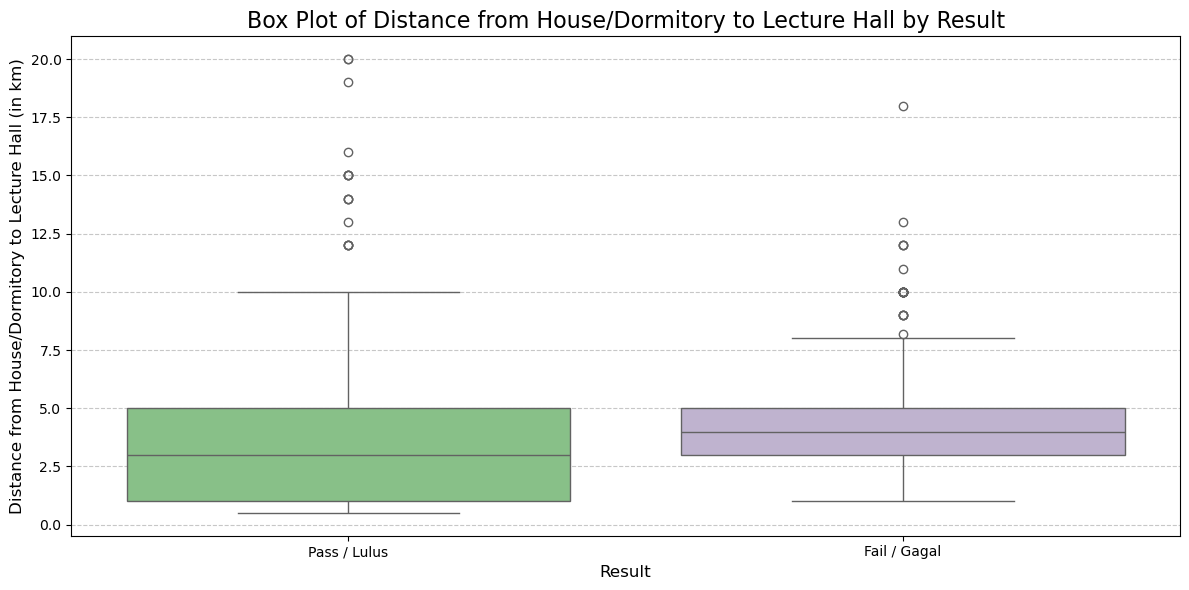

In [173]:
distance_data = data[['n_distance', 'c_result']].dropna()

# Creating a box plot to visualize the distribution of distance from house/dormitory to lecture hall by result
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=distance_data,
    x='c_result',
    y='n_distance',
    palette='Accent'
)

# Customizing the plot
plt.title('Box Plot of Distance from House/Dormitory to Lecture Hall by Result', fontsize=16)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Distance from House/Dormitory to Lecture Hall (in km)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Shahzwan\AppData\Local\Temp\ipykernel_14992\3922843521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


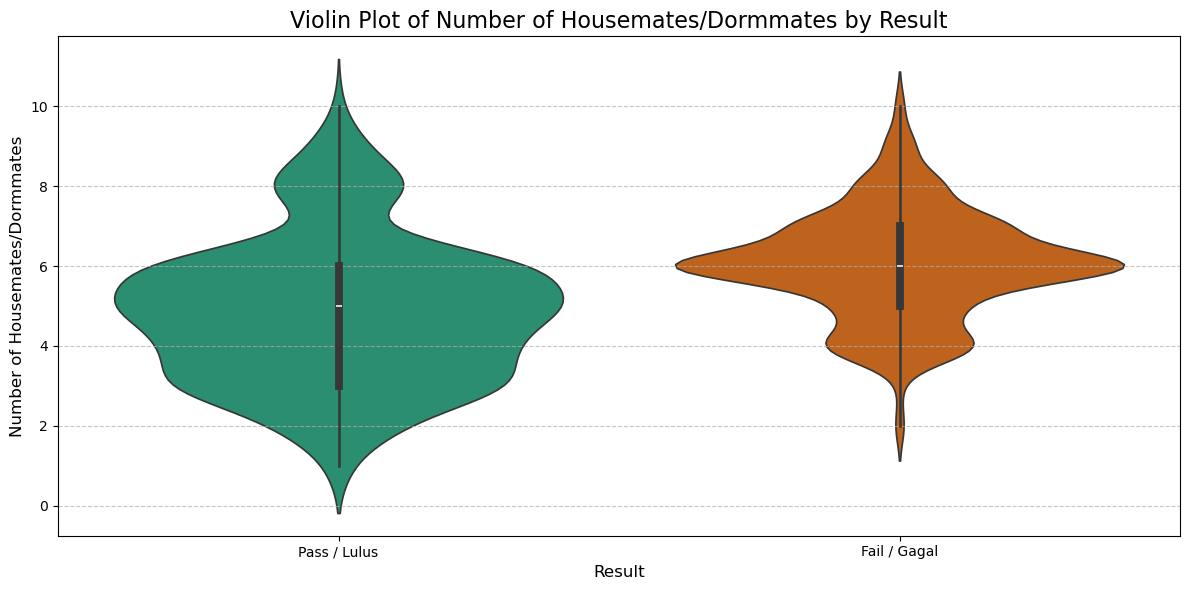

In [177]:
housemates_data = data[['n_housemate', 'c_result']].dropna()
# Creating a violin plot to visualize the distribution of the number of housemates/dormmates by result
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=housemates_data,
    x='c_result',
    y='n_housemate',
    palette='Dark2'
)

# Customizing the plot
plt.title('Violin Plot of Number of Housemates/Dormmates by Result', fontsize=16)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Number of Housemates/Dormmates', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


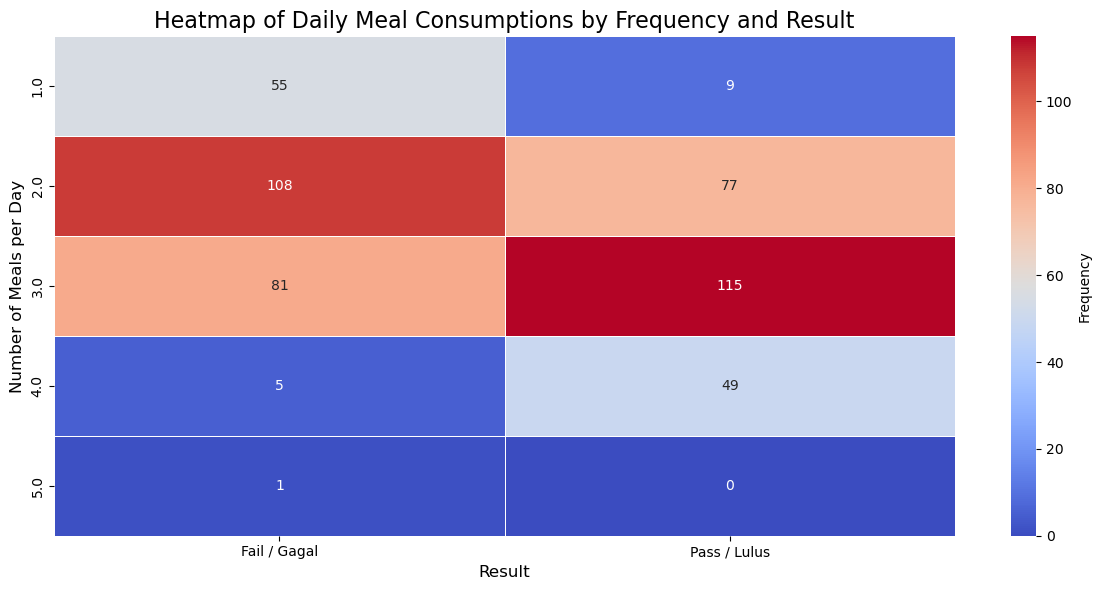

In [181]:
meal_heatmap_data = data[['n_housemate', 'c_result']].dropna()
# Recalculating the frequency data and converting it to integer format for the heatmap
meal_heatmap_data = meal_data.groupby(['n_meals', 'c_result']).size().unstack().fillna(0).astype(int)

# Creating the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    meal_heatmap_data,
    annot=True,
    cmap='coolwarm',
    fmt='d',  # Displaying as integers
    linewidths=0.5,
    cbar_kws={'label': 'Frequency'}
)

# Customizing the plot
plt.title('Heatmap of Daily Meal Consumptions by Frequency and Result', fontsize=16)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Number of Meals per Day', fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\Shahzwan\AppData\Local\Temp\ipykernel_14992\4277041225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


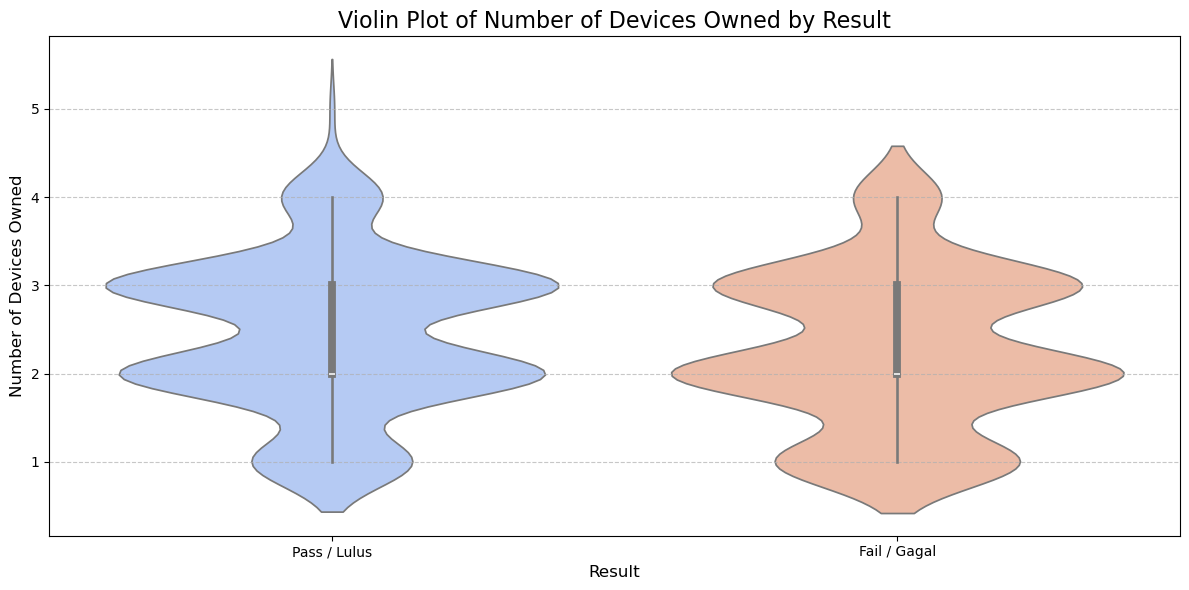

In [183]:
devices_data = data[['n_devices', 'c_result']].dropna()
# Creating a violin plot to visualize the distribution of the number of devices owned by result
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=devices_data,
    x='c_result',
    y='n_devices',
    palette='coolwarm'
)

# Customizing the plot
plt.title('Violin Plot of Number of Devices Owned by Result', fontsize=16)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Number of Devices Owned', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()
